# 05 (draft)  Third fit

|                     |     |
| ------------------- | --- |
| **Status**          | Draft |
| **Source**          | Y. Alcaraz Galván; outputs computed from the Tank dataset snapshot (P. Broqvist) and NMR data from experiments; Gogoi et al., J. Phys. Chem. C 2024, 128, 1654 |
| **Scope**           | The third fit (run 2026-10-07 to 2026-10-08) |
| **Builds on**       | `scripts/run_fit.py` (computes the fits); results in `notebooks/results/05_fit3/`; `kinetics/fitting/reporting.py` (the comparisons drawn here) |
| **See also**        | [plan-fit_improvement.md](../docs/plan-fit_improvement.md) (why this fit was run) · [reference-fit_models.md](../docs/reference-fit_models.md) (the models) · `05_first_fit_DRAFT.ipynb` (the second fit) |

In [52]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make the repository importable whether the notebook runs from notebooks/ or from the repository root
REPO = Path.cwd() if (Path.cwd() / 'kinetics').is_dir() else Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
from IPython.display import display

from kinetics.constants import KB_EV
from kinetics.data import describe_lab_observables, load_lab_observables, tabulate_observable_shares
from kinetics.data.observables import calculate_replicate_scatter
from kinetics.fitting import FIT_STRUCTURES, REPORT_SOLVER, FitProblem, build_sample_set, find_confidence_interval, get_structure, load_fit_result
from kinetics.fitting.candidates import BARRIER_BOX_EV, tabulate_reaction_barriers
from kinetics.fitting.estimation import get_profile_theta
from kinetics.fitting.reporting import (
    calculate_parameter_correlation, evaluate_fit, load_measured_spectra, simulate_fit_trajectories, tabulate_fit_shares,
    tabulate_window_amounts,
)
from demo import fit_plots, style, tables

style.apply_style()
pd.set_option('display.max_colwidth', None)

RESULTS = REPO / 'notebooks' / 'results' / '05_fit3'   # the third fit, written by scripts/run_fit.py
LADDER = list(FIT_STRUCTURES)                          # the models, simplest first
MAIN = 'M3-split'                                      # the model the notebook looks at (§4)
AGES = {'short': '1 h', 'middle': '1 day', 'long': '7 days', 'free': 'free ages'}   # scenario in the result files → reading
FITTING = ('middle', 'long', 'free')                   # the readings under which M3-split fits
DELTA_CHI2 = 3.84                                      # rise of χ² that ends a 95 % interval
BARRIER_NAMES = {'g hydrolysis_R1': 'first hydrolysis (R1)', 'g hydrolysis_R23': 'second and third\nhydrolysis (R2, R3)',
                 'g transfer': 'transfer (R5–R7)', 'g condensation': 'condensation (R4)', 'g solvent_attack': 'solvent attack (R8, R9)'}
SHORT_NAMES = {'g hydrolysis_R1': 'barrier R1', 'g hydrolysis_R23': 'barrier R2, R3', 'g transfer': 'barrier transfer',
               'g condensation': 'barrier condensation', 'g solvent_attack': 'barrier solvent attack', 'dG R1': 'energy R1',
               'dG R2': 'energy R2', 'dG R3': 'energy R3', 'dG R4': 'energy R4', 'c0 H2O TMSPa alone': 'water of TMSPa alone',
               'log10 age 2 % H2O': 'age of 2 % H2O'}
PHOSPHATE_TUBES = ['0.5 % H2O', '2 % H2O', 'TMSPa + TMSOH (A)', 'TMSPa alone']       # tubes with a ³¹P spectrum
SILYL_TUBES = ['0.5 % H2O', '2 % H2O', 'TMSOH, probe', 'TMSOH, glovebox']            # tubes with a fitted ¹³C spectrum
WAITING_TUBES = ['0.5 % H2O', '2 % H2O', 'TMSPa alone']                              # mixed with TMSPA and no TMSOH


def by_age(table, scenarios=FITTING):
    # Columns of a table pivoted by scenario: put in order and named by the reading
    return table.reindex(columns=list(scenarios)).rename(columns=AGES).rename_axis(columns='reading')


def tabulate_accepted_ranges(scenario):
    # ΔG‡ and ΔG_rxn of each reaction over the accepted sets: the fit and every profile point within Δχ² = 3.84 of it
    profile = profiles[scenario]
    thetas = [fits[scenario]['theta']] + [get_profile_theta(row) for _, row in profile[profile['chi2'] - fits[scenario]['chi2'] <= DELTA_CHI2].iterrows()]
    values = [tabulate_reaction_barriers(get_structure(MAIN), theta) for theta in thetas]
    return pd.DataFrame([{'structure': MAIN, 'scenario': scenario, 'reaction': r,
                          'dG‡ low': min(v[r]['dG_barrier_eV'] for v in values), 'dG‡ high': max(v[r]['dG_barrier_eV'] for v in values),
                          'dG_rxn low': min(v[r]['dG_rxn_eV'] for v in values), 'dG_rxn high': max(v[r]['dG_rxn_eV'] for v in values)}
                         for r in values[0]])


summary, parameters, barriers, residuals = (pd.read_csv(RESULTS / f'fits_{name}.csv') for name in ('summary', 'parameters', 'barriers', 'residuals'))
observables = load_lab_observables()
fits = {scenario: load_fit_result(str(RESULTS / 'fits' / f'{MAIN}__{scenario}.json')) for scenario in FITTING}
profiles = {scenario: load_fit_result(str(RESULTS / 'profiles' / f'{MAIN}__{scenario}.json'))['profile'] for scenario in FITTING}
intervals = pd.DataFrame([{**find_confidence_interval(profile, name), 'structure': MAIN, 'scenario': scenario}
                          for scenario, profile in profiles.items() for name in dict.fromkeys(profile['parameter'])])
bands = pd.concat([tabulate_accepted_ranges(scenario) for scenario in FITTING], ignore_index=True)

# What each stored parameter set predicts, spectrum by spectrum (run forward; nothing is fitted)
views = {scenario: evaluate_fit(fits[scenario], observables) for scenario in FITTING}
shares = {scenario: tabulate_fit_shares(view) for scenario, view in views.items()}
print(f"{MAIN}: " + ' · '.join(f"{AGES[s]}: χ² {fits[s]['chi2']:.1f}, worst miss {fits[s]['max_abs_z']:.2f}" for s in FITTING))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
M3-split: 1 day: χ² 45.9, worst miss 2.96 · 7 days: χ² 44.6, worst miss 2.56 · free ages: χ² 35.3, worst miss 1.93


## 1. What was measured

TMSPA is a phosphate with three silyl groups. They can leave it one by one: TMSPA → BMSPA → MMSPA → H₃PO₄.

| Family | Reactions | Description |
|---|---|---|
| hydrolysis | R1: TMSPA + H₂O ⇌ BMSPA + TMSOH<br>R2: BMSPA + H₂O ⇌ MMSPA + TMSOH<br>R3: MMSPA + H₂O ⇌ H₃PO₄ + TMSOH | water takes one silyl group off the phosphate and leaves as TMSOH |
| condensation | R4: 2 TMSOH ⇌ HMDSO + H₂O | two TMSOH join and give the water back |
| transfer | R5–R7: the three steps of hydrolysis with TMSOH in place of H₂O, each giving HMDSO | TMSOH takes the silyl group; no water is needed |
| solvent attack | R8: EC + TMSOH ⇌ TMSOEG + CO₂ (R9: a second EC) | TMSOH opens the solvent |

### 1.2 The tubes

All tubes are in the same solvent (EC/DEC). Each one isolates a part of the chemistry. The names are those of the data files.

| Name in the files | What was mixed | What happened to it | What it shows |
|---|---|---|---|
| `0.5 % H2O` | TMSPA (149 mM) + a little water (263 mM) | room temperature; one ³¹P and one ¹³C spectrum | with little water TMSPA survives: 93 % is still there |
| `2 % H2O` | TMSPA (149 mM) + four times more water (1 052 mM) | six ³¹P and six ¹³C spectra over six days; warmed for about 17 min to 30, 40 … 80 °C between them | TMSPA is gone and the mixture has stopped: 66 % H₃PO₄ and 32 % MMSPA in all six spectra |
| `TMSPa + TMSOH (A)` | TMSPA (149 mM) + TMSOH (180 mM), no water | room temperature; one ³¹P spectrum | TMSOH alone takes silyl groups off TMSPA: 69 % BMSPA |
| `TMSPa alone` | TMSPA (149 mM), nothing added | room temperature; two ³¹P spectra, 243 h apart | the only tube seen changing: from 81 % to 23 % TMSPA. It must have held water; how much is not known |
| `TMSOH, probe` | TMSOH (450 mM), no phosphate | three ¹³C spectra over six days; heated to 80 °C for about 9 min **inside the NMR probe** (the part of the spectrometer that holds the tube) | at room temperature TMSOH leaves the solvent alone |
| `TMSOH, glovebox` | TMSOH (450 mM), no phosphate | stirred at 80 °C **in a glovebox** (a closed, dry box), then one ¹³C spectrum. The 8 h are taken from the paper | at 80 °C TMSOH opens the solvent (43 % TMSOEG) and condenses (16 % HMDSO) |
| `E1` | TMSOH in EC | not a tube of this lab: a statement of the paper | after a week at room temperature less than 2 % of the TMSOH has opened the solvent |

- **Why the two TMSOH tubes matter.** They hold no phosphate, so only condensation and solvent attack can happen in them. "Probe" and "glovebox" only say where each tube was heated: for minutes inside the spectrometer, or for hours in the box.
- **Kept out of the fit:** two measurements, compared with the model only after the fit. Neither is shown in this notebook.
  - `TMSPa + TMSOH (B)`, a second tube with the recipe of tube A. It was recorded with few scans, so its shares are too noisy to weigh in the fit (errors of 0.08 to 0.18).
  - A ¹³C spectrum of tube A recorded ten days later (`check` in the table below). Its folder carries the title of another sample, so its origin is not certain.
- **Table below:** the same tubes as the observables file holds them.

In [53]:
describe_lab_observables(observables).query("role == 'fit'")[['spectra', 'solutes at t = 0', 'before the first spectrum', 'heated after the first spectrum']]

,spectra,solutes at t = 0,before the first spectrum,heated after the first spectrum
0.5 % H2O,1 31P + 1 13C,"TMSPA 149 mM, H2O 263 mM",unknown (age),—
2 % H2O,6 31P + 6 13C,"TMSPA 149 mM, H2O 1052 mM",unknown (age),"30 °C × 17 min, 40 °C × 17 min, 50 °C × 18 min, 60 °C × 18 min, 70 °C × 17 min, 80 °C × 18 min"
TMSPa + TMSOH (A),1 31P + 1 13C (check),"TMSPA 149 mM, TMSOH 180 mM",unknown (age),—
TMSPa alone,2 31P,"TMSPA 149 mM, H2O unknown",unknown (age),—
"TMSOH, probe",3 13C,TMSOH 450 mM,unknown (age),80 °C × 9 min
"TMSOH, glovebox",1 13C,TMSOH 450 mM,80 °C × 8 h,—


### 1.3 What a spectrum gives the fit

- **³¹P:** one line per phosphate (TMSPA, BMSPA, MMSPA, H₃PO₄). The size of a line is the share of the phosphorus in that species.

- **¹³C:** one line per form of the silyl group (TMSOH, HMDSO, TMSOEG, still on phosphate). The size of a line is the share of the silyl groups in that form.

- The fit is scored against 85 values: 81 measured (the shares of every tube, and the limit E1) and 4 computed reaction energies (§3).

- The six spectra of `2 % H2O` show the same mixture, so they are not six separate measurements of it. Each share enters as its mean over the six spectra (what the mixture is) and five differences from that mean (that it did not change).

- **Not measured:** water, and the age of the tubes (§6).

--> §1 hands over seven fitted tubes and 85 values. §2 shows them against the fitted model.

### 1.4 The models and the ages

**Two kinds of number describe a reaction**

- **Barrier:** how fast the reaction goes.
- **Reaction energy:** where it stops. DFT gives a value with an uncertainty.

**The models.**

Each one lets the fit choose more numbers than the one before.

| Model | Numbers the fit chooses | Why try it |
|---|---|---|
| M0 | 1 barrier, the same for all nine reactions | the simplest model possible |
| M1 | 4 barriers, one per family (§1.1) | the families are different chemistry |
| M1-split | 5 barriers: R1 apart from R2 and R3 | the first silyl group may leave at another speed than the next two |
| M3 | 4 barriers + 4 reaction energies (R1–R4) | the DFT energies are uncertain, so they may move |
| M3-split | 5 barriers + 4 reaction energies | both changes together |

- **One more number in every model:** the water in `TMSPa alone` at mixing.
  - **Why:** no water was added to this tube, yet its TMSPA fell from 81 % to 23 % in ten days (243 h between the two spectra). That reaction needs water, so the tube held some.
  - **How much:** not measured, because no spectrum shows water. The fit chooses it, between 0 and 300 mM.


**The ages.** 

The age of a tube is the time from mixing to its first spectrum. Nobody wrote it down, so every model is fitted under four assumptions.

| Name | Meaning |
|---|---|
| 1 h | every tube was 1 h old at its first spectrum |
| 1 day | every tube was 1 day old |
| 7 days | every tube was 7 days old |
| free ages | each tube has its own age, between 1 h and 30 days, chosen by the fit |

## 2. The fit against the measurements

- **The model:** the reactions of 1.1, with ten numbers found by the fit: 
  - 5 barriers, 
  - 4 reaction energies and 
  - the water of `TMSPa alone`.

- **The ages:** the fit also chooses how old each tube was at its first spectrum (6).


### 2.1 NMR spectra: measured and simulated

- **Yellow:** the measured spectrum.

- **Window (grey box):** the stretch of the axis where one species gives its line.
  - The area of the spectrum inside a window, divided by the area in all the windows, is the **share** of that species.
  - The fit uses only these shares, not the shape of the spectrum.

- **Blue:** the spectrum simulated from the fit, made in two steps:
  1. the model is run from the recipe of the tube to the time of the spectrum. This gives the concentration of every species, and from it the share of each window;

- **How to read:** blue on top of grey means that model and measurement agree. The two numbers in a window are its share: measured / simulated.

- **Display:** both curves are smoothed by the same amount, so that the height of a line follows its area.


In [ ]:
spectra = load_measured_spectra(observables)        # the raw spectra behind the shares (needs LAB_NMR_DIR)
phosphate_rows = [('0.5 % H2O', 0, ''), ('2 % H2O', 0, 'spectrum 1 of 6'), ('TMSPa + TMSOH (A)', 0, ''),
                  ('TMSPa alone', 0, 'first spectrum'), ('TMSPa alone', 1, '243 h later')]
# The four simpler models of the ladder (§4), free ages, drawn over the same spectra
simpler = {f'{name} fitted': tabulate_fit_shares(evaluate_fit(load_fit_result(str(RESULTS / 'fits' / f'{name}__free.json')), observables))
           for name in ('M0-Marcus', 'M1', 'M1-split', 'M3')}
fit_plots.plot_spectra_comparison(spectra, simpler, nucleus='31P', overlay=True, rows=phosphate_rows,
                                  title='³¹P spectra of the four tubes that hold phosphate: measured, and the four simpler models (free ages)');

KeyboardInterrupt: 

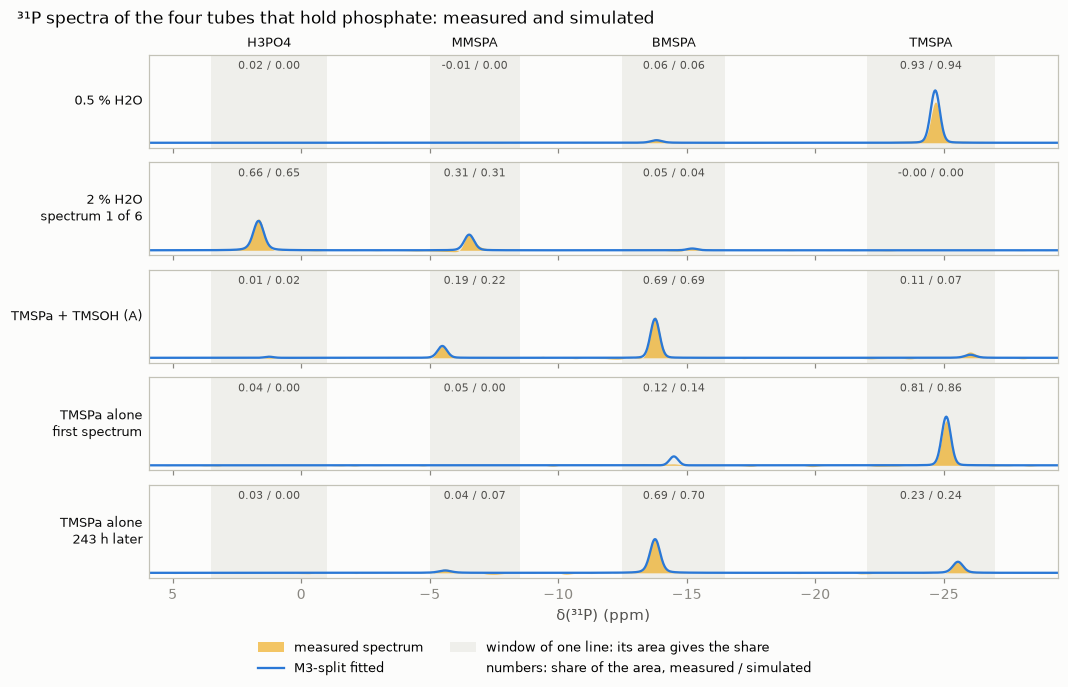

In [ ]:
fit_plots.plot_spectra_comparison(spectra, shares['free'], nucleus='31P', fit_label=f'{MAIN} fitted', rows=phosphate_rows,
                                  title='³¹P spectra of the four tubes that hold phosphate: measured and simulated');

,nucleus,spectrum (0 = first),line,measured,simulated,error,miss
the five largest misses,,,,,,,
"TMSOH, probe",13C,2,HMDSO,0.06,0.01,0.04,-1.31
"TMSOH, probe",13C,1,HMDSO,0.06,0.01,0.04,-1.29
2 % H2O,13C,3,P-silyl,0.04,0.13,0.07,1.20
TMSPa alone,31P,0,MMSPA,0.05,0.00,0.04,-1.09
2 % H2O,13C,5,P-silyl,0.07,0.13,0.06,1.02


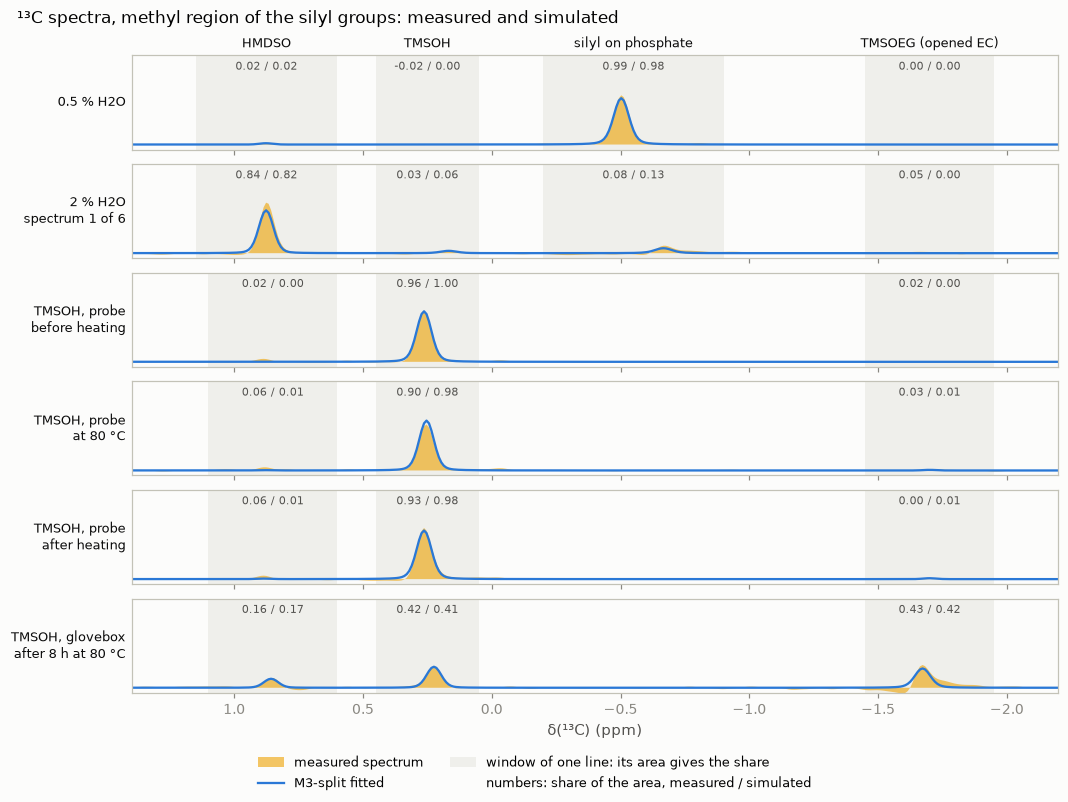

In [ ]:
fit_plots.plot_spectra_comparison(spectra, shares['free'], nucleus='13C', fit_label=f'{MAIN} fitted', title='¹³C spectra, methyl region of the silyl groups: measured and simulated',
                                  rows=[('0.5 % H2O', 0, ''), ('2 % H2O', 0, 'spectrum 1 of 6'), ('TMSOH, probe', 0, 'before heating'),
                                        ('TMSOH, probe', 1, 'at 80 °C'), ('TMSOH, probe', 2, 'after heating'), ('TMSOH, glovebox', 0, 'after 8 h at 80 °C')]);
gap = shares['free'].assign(miss=lambda d: (d['predicted'] - d['measured']) / d['sigma'])
gap.loc[gap['miss'].abs().nlargest(5).index, ['sample', 'nucleus', 'spectrum', 'window', 'measured', 'predicted', 'sigma', 'miss']].round(2).rename(
    columns={'spectrum': 'spectrum (0 = first)', 'window': 'line', 'predicted': 'simulated', 'sigma': 'error'}).set_index('sample').rename_axis('the five largest misses')

**Conclusions**

- Over the 80 shares of the fitted spectra the largest miss is -1.3 (see table).

- Where the two numbers differ, the line is small: the model gives no H₃PO₄ or MMSPA in the first spectrum of `TMSPa alone` (0.04 and 0.05 measured), and less HMDSO in `TMSOH, probe` than measured (0.01 against 0.06). All are inside their errors.

---

### 2.2 Concentrations in time: the model alone

Why nothing happens for a long time, and then everything at once?

- A tube starts with no TMSOH: 
The model needs TMSOH to react fast, and at mixing there is none.

- The first TMSOH comes slowly: 
Only the slow reaction with water makes it. This is the long flat part.

- Once there is some, it multiplies. 
TMSOH takes a silyl group and gives HMDSO; HMDSO and water give two TMSOH back. More TMSOH makes the reaction faster, which makes more TMSOH. This is the fall.

- It stops when something runs out: 
the TMSPA, or the water (`TMSPa alone`).

**Careful: the time of the fall is not measured**

- Nobody recorded when the tubes were mixed. The fit chooses the age of each tube, and with it where the spectra sit on the time axis.

- The spectra only say how each tube ends. No spectrum was taken during a fall.

- So the shape "wait, then fall" comes from the model and from the start without TMSOH, not from the data. 6 tests how much it can be trusted.


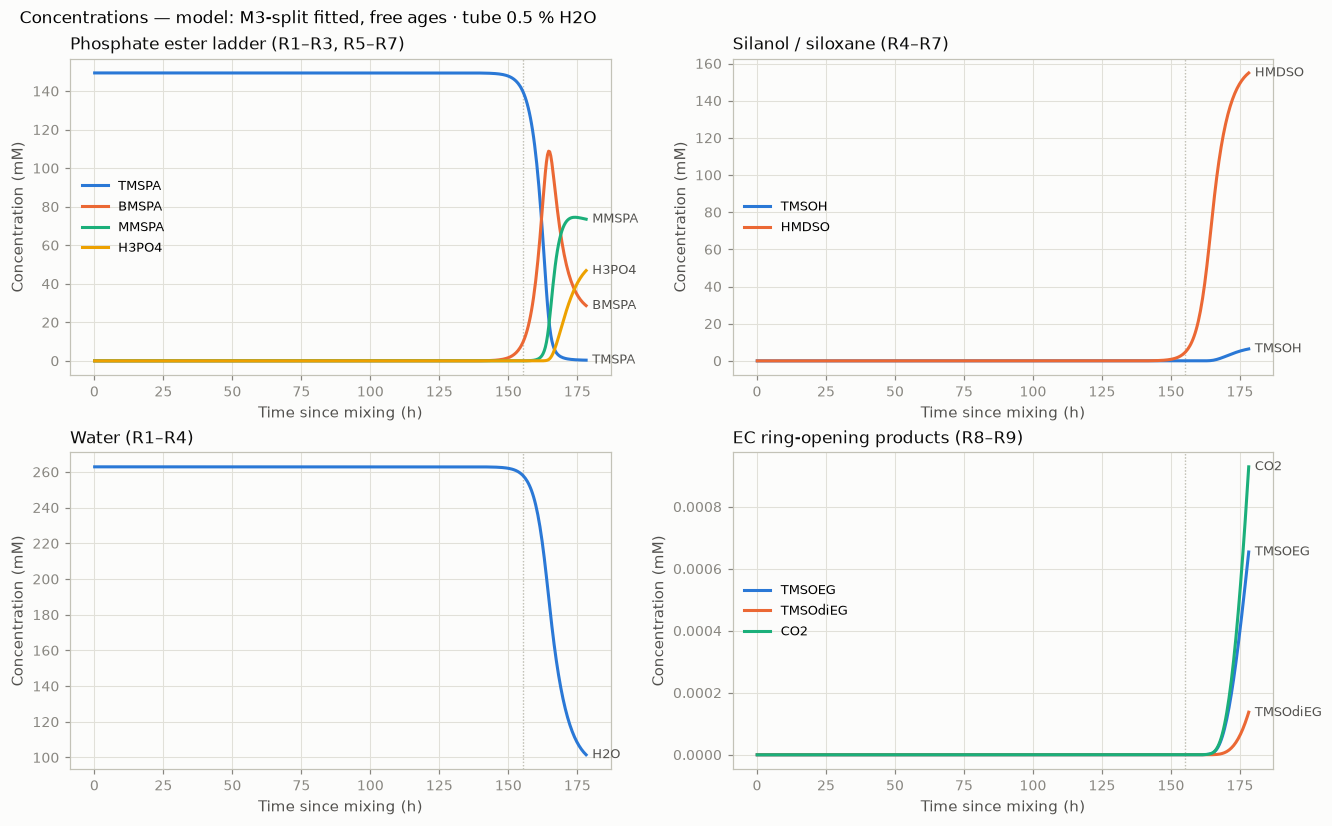

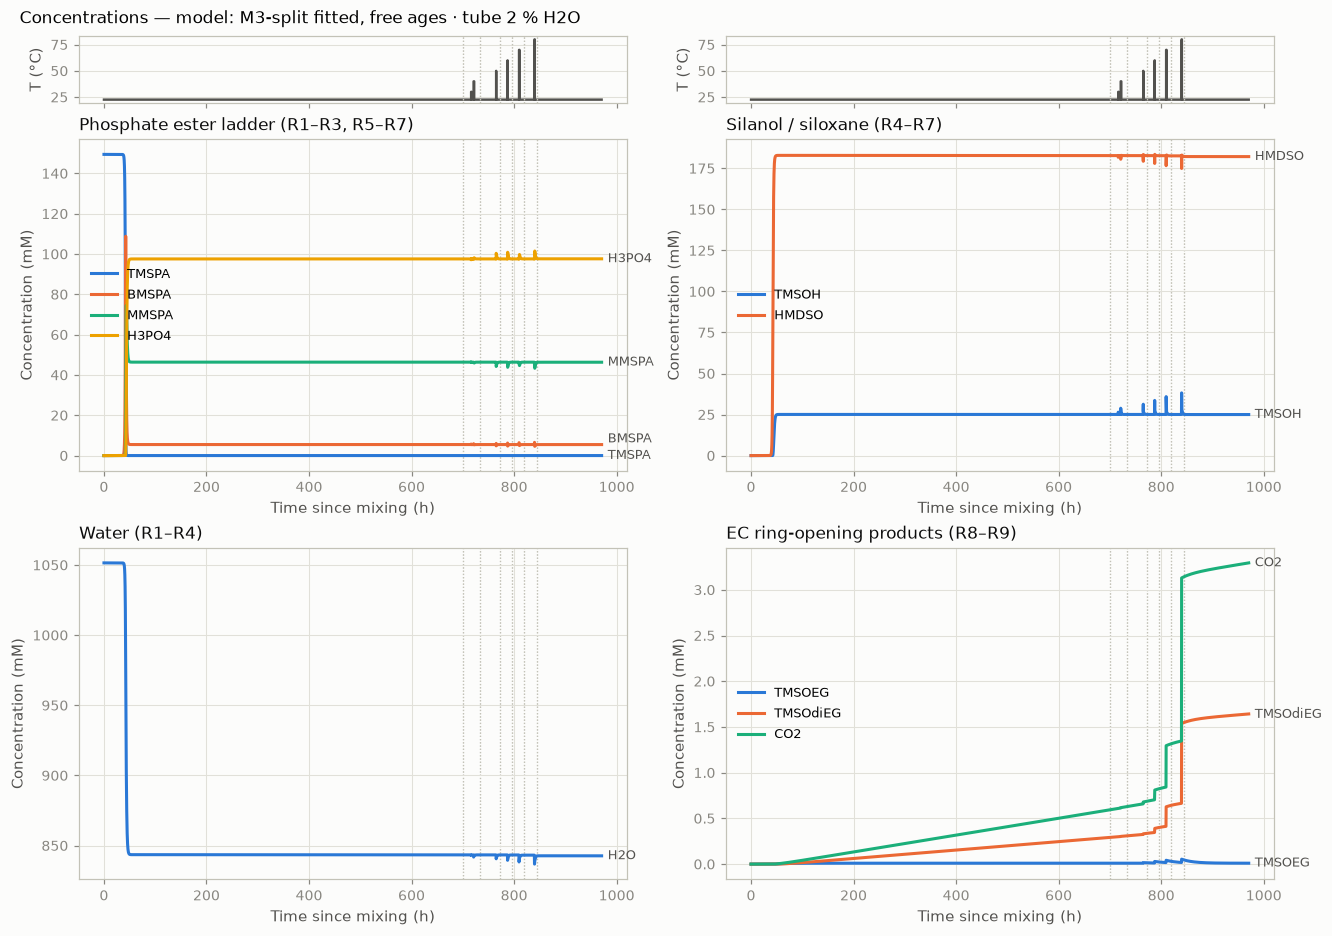

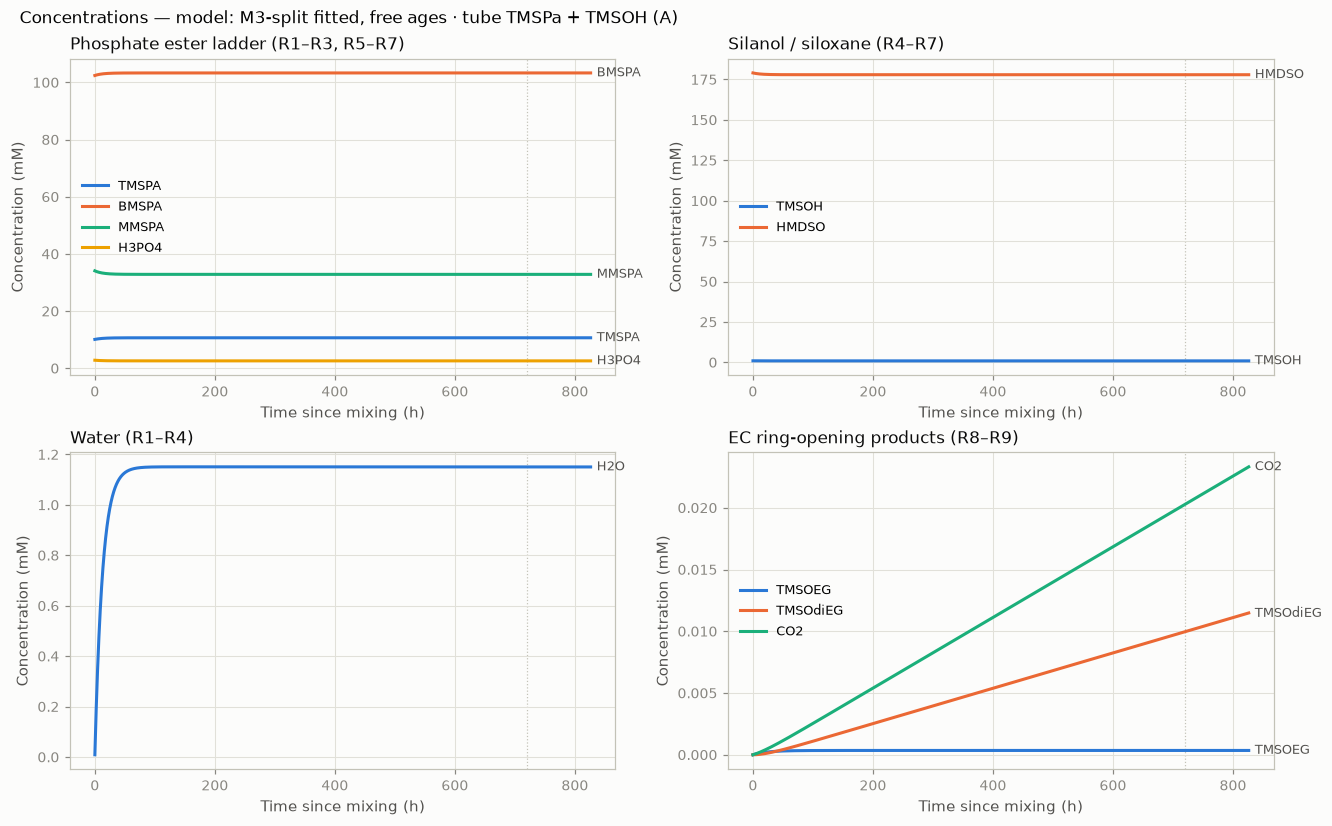

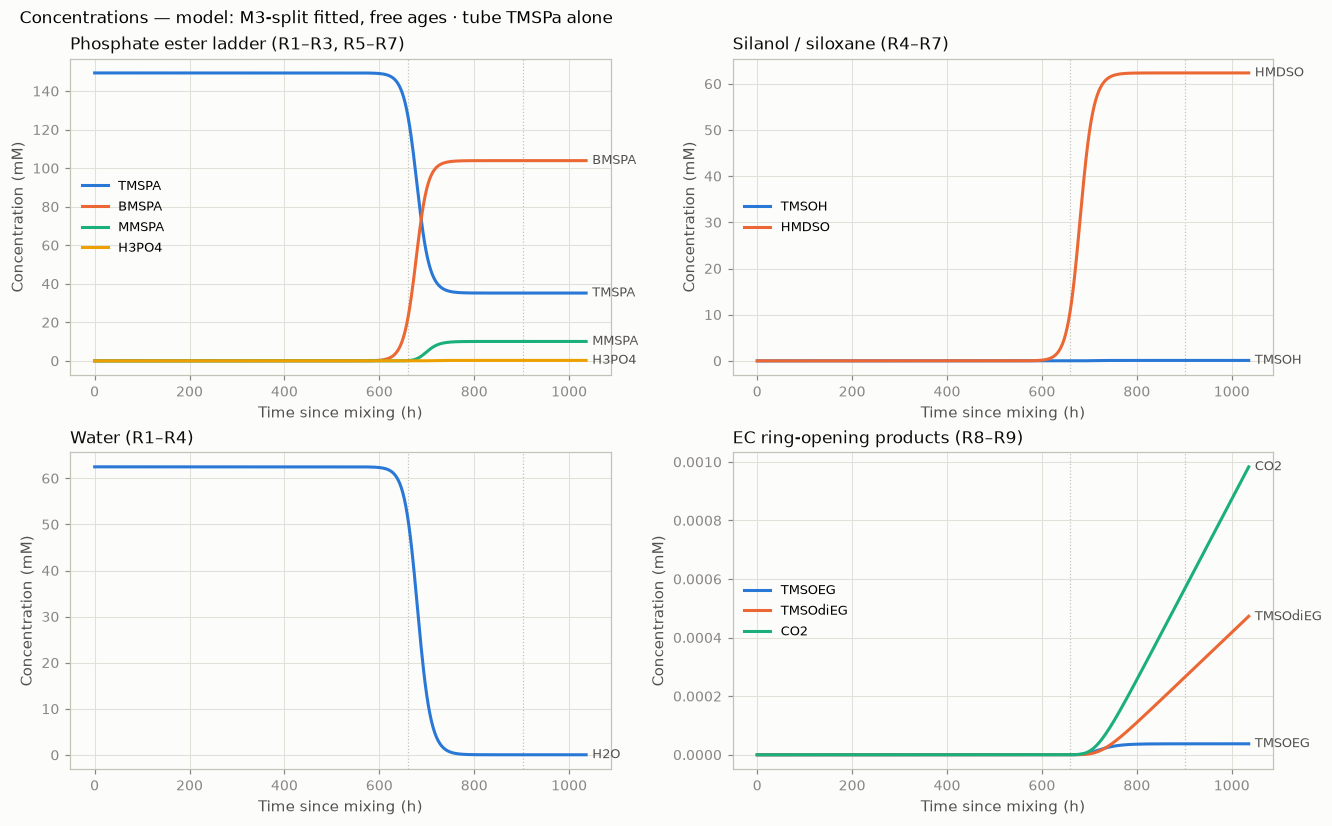

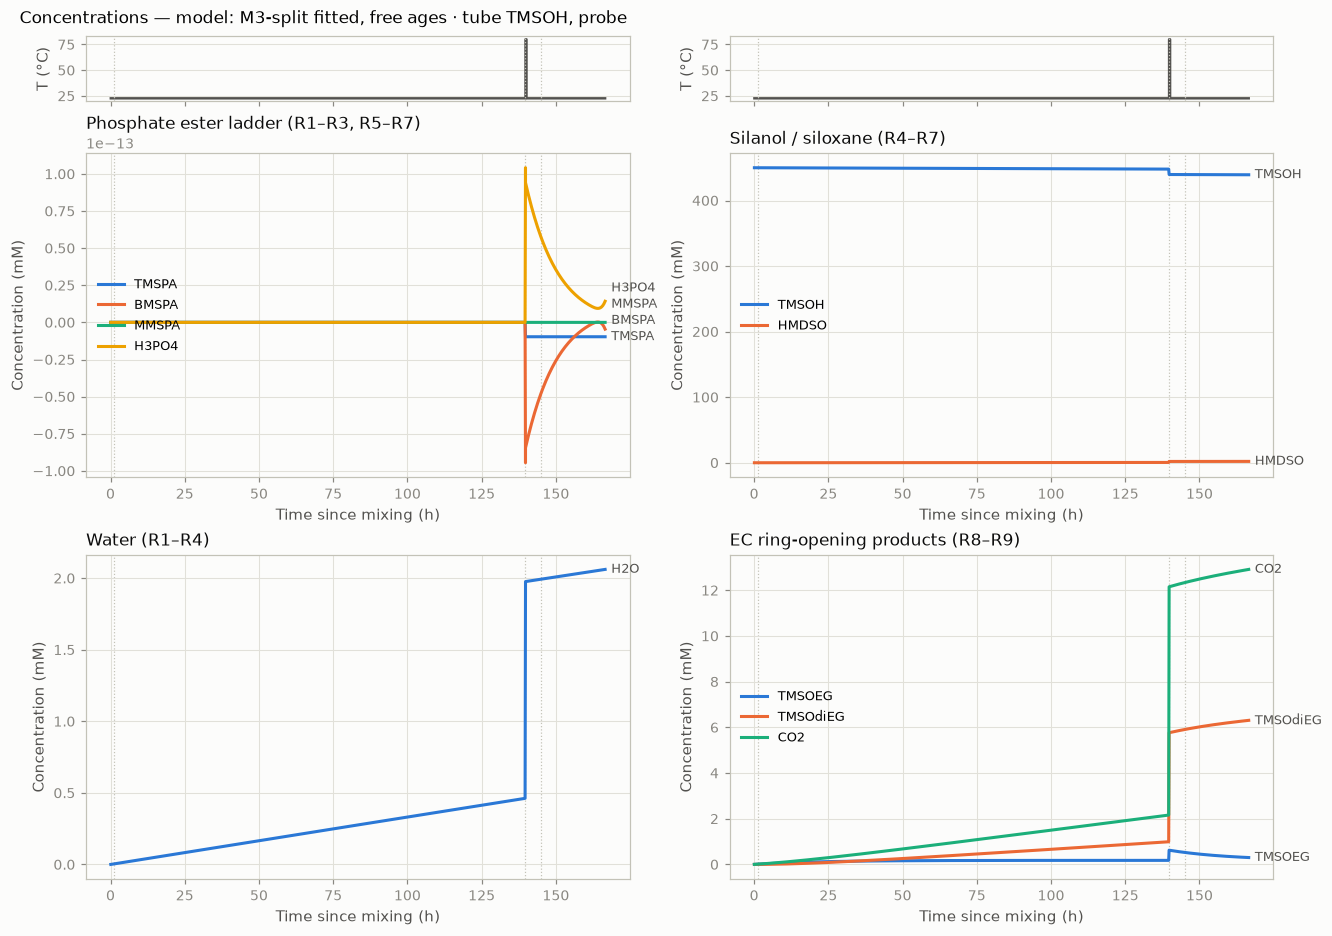

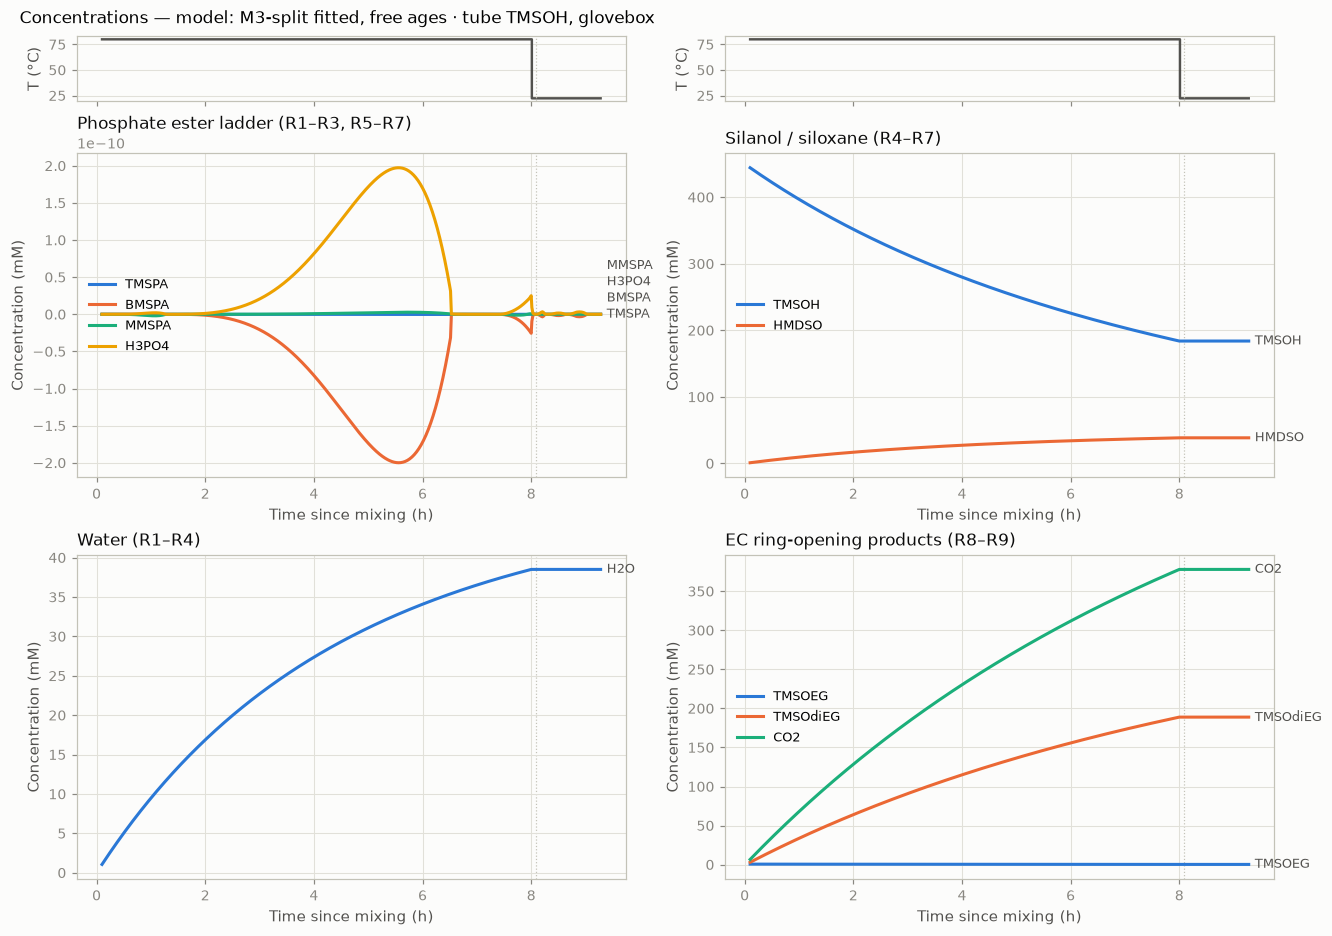

In [ ]:
# The model alone: every species of each tube since mixing, one figure per tube (a fall needs a fine time grid)
trajectories = simulate_fit_trajectories(views['free'], until_h=1500.0, n_points=4000)
spectrum_times = shares['free'].groupby('sample')['t_h'].unique()
for tube in PHOSPHATE_TUBES + ['TMSOH, probe', 'TMSOH, glovebox']:
    fit_plots.plot_tube_concentrations(trajectories, tube, spectrum_times[tube], model=f'{MAIN} fitted, free ages')

1. The data hold no kinetics: 
Almost every tube was measured once, either finished or not yet started. The fit had to invent the whole path from mixing to the spectrum, with no point in between to guide it.

2. The fit used the ages to make things match, not to describe the tubes.: 
It may choose when each tube was measured, so it puts each spectrum where it suits: a month after mixing in three tubes, and just before the fall in `0.5 % H2O`. The step-shaped curves are the visible sign of this.

3. In `2 % H2O`, `TMSPa + TMSOH (A)` and `TMSPa alone` it gives the final composition. That rests on the reaction energies, not on time. The barriers, which set the speed, remain unchecked.


- The result can defend where each mixture ends. The model can't be used to predict times, such as how long a stored electrolyte lasts.

- **What is missing:** one tube followed in time from mixing. With it the curves would no longer be free.

The curves show that this fit has too much freedom in time.

---

## 3. How a fit is made and scored

**What this part delivers:** the two kinds of fitted number, the path from a set of numbers to χ², and the rule that says "fits".

**The two kinds of fitted number**

- **g**, the intrinsic barrier of a family of reactions. It sets how fast a reaction goes.
- **ΔG_rxn**, the reaction energy of R1–R4. It sets where a reaction stops. DFT gives it with an uncertainty: ΔG_rxn(DFT) ± σ.

**From a set of values to χ²**

```mermaid
%%{init: {"themeVariables": {"fontSize": "11px"}}}%%
flowchart TD
    NMR["NMR spectrum"] --> AREAS["peak areas A_i"]
    AREAS --> SHARES["measured shares<br/>s_i ± σ_i"]
    TRIAL["one trial: all g, all ΔG_rxn,<br/>the water of 'TMSPa alone'"] --> MODEL["(1) ΔG‡ from g and ΔG_rxn (Marcus)<br/>(2) k_f, K, k_r<br/>(3) simulate each tube from its recipe<br/>to the time of its spectrum<br/>(4) predicted shares"]
    SHARES --> CHI2["(5) χ²"]
    MODEL --> CHI2
    CHI2 --> OPT["another trial (all values move together), until χ² is smallest"]
```

Measured share

$$s_i = A_i / \sum_j A_j$$

i, j: the peaks of one NMR spectrum (one per species).

(1) Barrier

$$\Delta G^\ddagger = g,(1 + \Delta G_{rxn}/4g)^2$$

(2) Rate constants

$$k_f = \frac{k_BT}{h},e^{-\Delta G^\ddagger/k_BT}, \qquad K = e^{-\Delta G_{rxn}/k_BT}, \qquad k_r = k_f/K$$

(3) Rate, e.g. R3

$$k_f,[\mathrm{MMSPA}][\mathrm{H_2O}] - k_r,[\mathrm{H_3PO_4}][\mathrm{TMSOH}]$$

(4) Predicted share, ³¹P

$$\frac{[\mathrm{MMSPA}]}{[\mathrm{TMSPA}]+[\mathrm{BMSPA}]+[\mathrm{MMSPA}]+[\mathrm{H_3PO_4}]}$$

(5) Score

$$\chi^2 = \sum \left(\frac{s_{pred}-s_{meas}}{\sigma_s}\right)^2 + \left(\frac{\Delta G_{rxn}-\Delta G_{rxn}(\mathrm{DFT})}{\sigma_{DFT}}\right)^2$$

s_pred, s_meas: predicted and measured share. σ_s: uncertainty of the measured share. The first sum runs over every measured share (all tubes, spectra and peaks).


- The second term of (5 Score) is the distance from DFT, counted in σ and squared. Staying at the DFT value costs 0, 1σ away costs 1, 2σ away costs 4.

- So ΔG_rxn is not shut inside DFT ± σ. It may move, but only when the NMR term improves by more than the move costs.

Fixed before any fit:

- The **miss** of one value is (predicted − measured) / error. A model fits when its worst miss is 3 or less.
- χ² adds all the squared misses into one number: it ranks the fits. The worst miss decides.
- Where the error of a share comes from, and whether it is the right size, is the subject of 7.2


## 4. Models

Each model adds one freedom to the one before it.

| Rung | Model | What is free | What it adds |
|---|---|---|---|
| 1 | M0 | 1 barrier | one barrier for all nine reactions (two variants: BEP and Marcus) |
| 2 | M1 | 4 barriers | one barrier per family |
| 3 | M1-split | 5 barriers | R1 separate from R2 and R3 |
| 4 | M3 | 4 barriers + 4 energies | M1 with the reaction energies of R1–R4 free |
| 5 | M3-split | 5 barriers + 4 energies | both additions together |

Each model is fitted four times, under four readings of the unknown ages (§6): every tube 1 h, 1 day or 7 days old, or free ages.


-Table: χ² (worst miss) of each model under each reading.
-Figure: the worst miss. A model fits where its point is inside the grey band.

"χ² (worst miss), ✓ = fits",free parameters,1 h,1 day,7 days,free ages
M0-BEP,2 (+1 age if free),4196 (60.1) ✗,4195 (60.1) ✗,4191 (60.0) ✗,4122 (57.6) ✗
M0-Marcus,2 (+1 age if free),4249 (59.7) ✗,4247 (59.7) ✗,4227 (59.3) ✗,4091 (56.3) ✗
M1,5 (+1 age if free),1786 (21.0) ✗,1668 (18.5) ✗,685 (19.7) ✗,565 (15.6) ✗
M1-split,6 (+1 age if free),1557 (21.6) ✗,488 (16.1) ✗,450 (15.8) ✗,280 (12.9) ✗
M3,9 (+1 age if free),777 (12.8) ✗,472 (18.2) ✗,381 (18.4) ✗,59 (3.2) ✗
M3-split,10 (+1 age if free),767 (12.9) ✗,46 (3.0) ✓,45 (2.6) ✓,35 (1.9) ✓


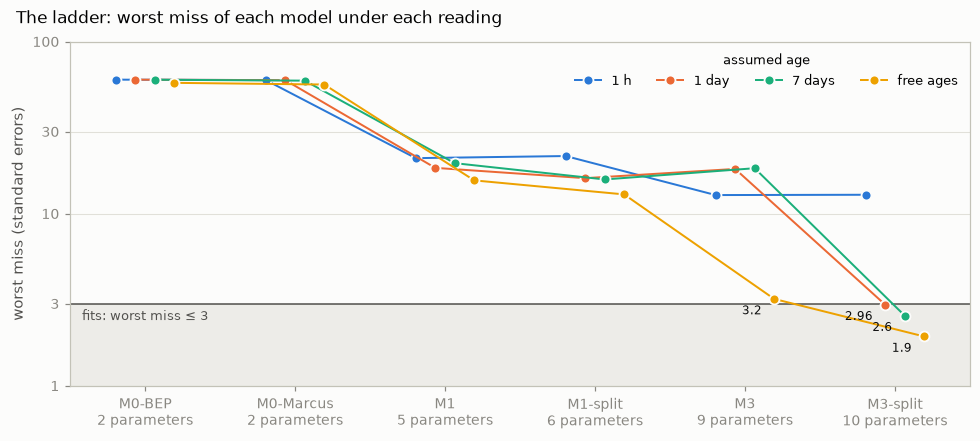

In [ ]:
fit_plots.plot_ladder(summary, order=LADDER, title='The ladder: worst miss of each model under each reading');
ordered = summary.assign(structure=pd.Categorical(summary['structure'], LADDER)).sort_values('structure')
tables.format_structure_table(ordered.assign(structure=ordered['structure'].astype(str))).rename(columns=AGES).rename_axis('χ² (worst miss), ✓ = fits', axis=1)

Only M3-split reaches the grey band: at 1 day (worst miss 2.96, just inside), not for 1h suposition

-M3 with free ages comes close: (3.2, on BMSPA in `0.5 % H2O`). In the second fit, made without `TMSPa alone`, it passed (2.5).

At 1 h nothing fits: one hour is not enough time for the tubes to react as observed.



### 4.2 What "does not fit" looks like

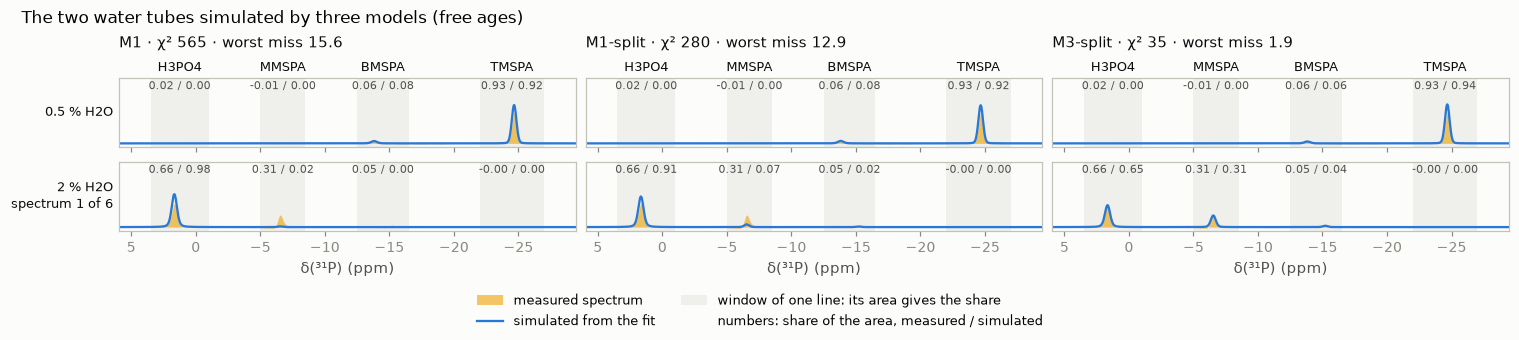

In [ ]:
rungs = {}
for name in ('M1', 'M1-split', MAIN):
    rung = load_fit_result(str(RESULTS / 'fits' / f'{name}__free.json'))
    rungs[f"{name} · χ² {rung['chi2']:.0f} · worst miss {rung['max_abs_z']:.1f}"] = tabulate_fit_shares(evaluate_fit(rung, observables))
fit_plots.plot_spectra_comparison(spectra, rungs, nucleus='31P', title='The two water tubes simulated by three models (free ages)',
                                  rows=[('0.5 % H2O', 0, ''), ('2 % H2O', 0, 'spectrum 1 of 6')]);

- **M1** (one barrier per family, computed energies) runs `2 % H2O` to H₃PO₄ alone: no MMSPA line, where 31 % is measured.
- **M1-split** does nearly the same (7 % MMSPA).
- **M3-split** is OK

--> M3-split is the model of the rest of the notebook.

## 5. Fit

**What this part delivers:** the fitted numbers of M3-split, how well the data hold each one, and whether they depend on each other.

### 5.1 Reaction energies: computed and fitted

- **Black tick with error bar:** ΔG_rxn from DFT ± σ.
- **Dot:** the ΔG_rxn the fit kept, under each reading. **Bar:** its range over the accepted sets, the parameter sets that fit almost as well as the best one (5.2).
- **Line at zero:** a reaction well below zero runs to the end; one near zero stops partway.
- **Last columns of the table:** the distance of each dot from DFT, in σ.

computed (eV)       fitted ΔG_rxn (eV)                  shift (in σ)  \
                ΔG_rxn   ± σ              1 day 7 days free ages        1 day   
reaction                                                                        
R1               -0.47  0.26              -0.06   0.03     -0.05         1.60   
R2               -0.16  0.25               0.03   0.12      0.04         0.78   
R3               -0.18  0.24               0.07   0.15      0.07         1.02   
R4                0.10  0.34              -0.14  -0.30     -0.14        -0.71   

                           
         7 days free ages  
reaction                   
R1         1.92      1.62  
R2         1.12      0.79  
R3         1.36      1.03  
R4        -1.21     -0.72

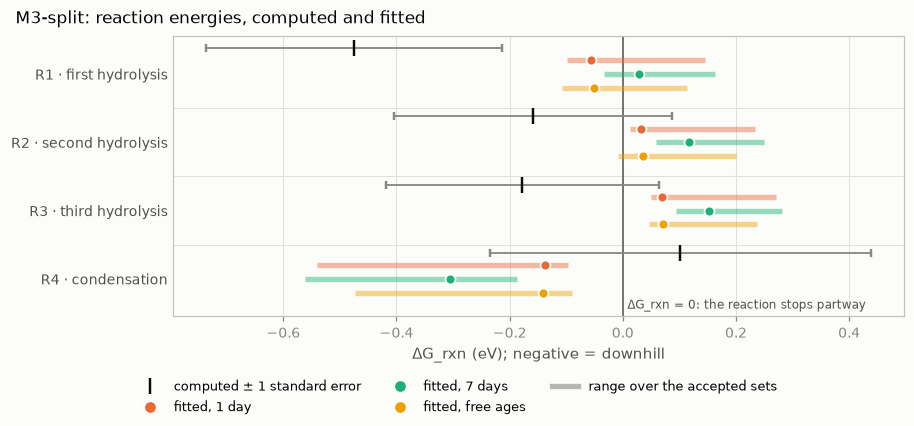

In [ ]:
main = barriers[barriers['structure'] == MAIN]
computed = barriers[(barriers['structure'] == 'M1') & (barriers['scenario'] == 'middle')].set_index('reaction')['dG_rxn_eV']   # M1 keeps the computed energies
pulls = residuals[(residuals['structure'] == MAIN) & (residuals['kind'] == 'prior')]
pulls = pulls.assign(reaction=pulls['quantity'].str.extract(r'\((R\d)\)')[0])
sigma = pulls.groupby('reaction')['sigma'].first()
display(pd.concat({'computed (eV)': pd.DataFrame({'ΔG_rxn': computed, '± σ': sigma}),
                   'fitted ΔG_rxn (eV)': by_age(main.pivot(index='reaction', columns='scenario', values='dG_rxn_eV')),
                   'shift (in σ)': by_age(pulls.pivot(index='reaction', columns='scenario', values='z'))}, axis=1).loc[['R1', 'R2', 'R3', 'R4']].round(2))
fit_plots.plot_energy_shifts(barriers, bands, structure=MAIN, computed=computed.to_dict(), sigma=sigma.to_dict(), scenarios=FITTING);

**How to read it**

- **Every dot is away from its tick, and none is far:** between 0.7σ and 1.9σ. A ±1σ window holds the true value about two times in three, so with four energies one or two outside it is ordinary.
- **Direction of the moves:** R2 and R3 go from downhill (−0.16, −0.18 eV) to above zero (+0.03 to +0.15 eV), R4 from uphill (+0.10 eV) to downhill, R1 from −0.47 eV to about zero.
- **1 day and free ages agree** to 0.01 eV. At 7 days every energy lies about 0.1 eV further from DFT (R4: 0.17 eV).
- **What this allows us to say:** with the energies exactly at DFT the model cannot describe the tubes (M1-split, 4.2); with the energies inside about twice DFT's own uncertainty it can. It is a statement of compatibility. It does not say that DFT is wrong, and it does not say that the model is right.

**Where an energy gets its value: `2 % H2O` by hand**

- A tube that has stopped changing has rate = 0 in step (3) of §3. For R3 that gives
  $K = \dfrac{[\mathrm{H_3PO_4}][\mathrm{TMSOH}]}{[\mathrm{MMSPA}][\mathrm{H_2O}]}$ and $\Delta G_{rxn} = -k_BT \ln K$.
- The cell below does this for `2 % H2O`: concentrations from its measured shares and its recipe, water from the balance.

In [ ]:
# The 2 % tube taken as being at equilibrium: K of R2, R3 and R4 from its measured shares and its recipe
kT = KB_EV * 295.65
recipe = observables['samples']['2 % H2O']['c0_M']
mean = residuals[(residuals['structure'] == MAIN) & (residuals['scenario'] == 'free') & (residuals['sample'] == '2 % H2O') & (residuals['kind'] == 'mean')]
share = mean.assign(line=mean['quantity'].str.split(' ').str[0]).set_index('line')['measured']
P, Si = recipe['TMSPA'], 3 * recipe['TMSPA']                       # phosphate and silyl groups in the tube (M)
C = {**{sp: share[sp] * P for sp in ('BMSPA', 'MMSPA', 'H3PO4')}, 'TMSOH': share['TMSOH'] * Si, 'HMDSO': share['HMDSO'] * Si / 2}
released = P * (share['BMSPA'] + 2 * share['MMSPA'] + 3 * share['H3PO4'])     # silyl groups that left the phosphate, one water each
C['H2O'] = recipe['H2O'] - released + C['HMDSO']                              # condensation gives one water back per HMDSO
display(pd.Series({sp: 1000 * c for sp, c in C.items()}).round(0).rename('mM').to_frame().T.rename_axis('2 % H2O, from its shares', axis=1))
K = {'R2': C['MMSPA'] * C['TMSOH'] / (C['BMSPA'] * C['H2O']), 'R3': C['H3PO4'] * C['TMSOH'] / (C['MMSPA'] * C['H2O']),
     'R4': C['HMDSO'] * C['H2O'] / C['TMSOH'] ** 2}
kept = main.pivot(index='reaction', columns='scenario', values='dG_rxn_eV')
pd.DataFrame({r: {'K from the shares': K[r], '−kT ln K (eV)': -kT * np.log(K[r]), 'fitted, free ages (eV)': kept.loc[r, 'free'],
                  'fitted, 7 days (eV)': kept.loc[r, 'long'], 'DFT (eV)': computed[r]} for r in K}).T.round(3)

"2 % H2O, from its shares",BMSPA,MMSPA,H3PO4,TMSOH,HMDSO,H2O
mM,6.0,47.0,99.0,28.0,193.0,848.0


,K from the shares,−kT ln K (eV),"fitted, free ages (eV)","fitted, 7 days (eV)",DFT (eV)
R2,0.285,0.032,0.035,0.118,-0.158
R3,0.070,0.068,0.071,0.152,-0.177
R4,202.975,-0.135,-0.140,-0.305,0.102


- **With free ages (and at 1 day) the hand values are the fitted values,** to 0.01 eV. For R2, R3 and R4 the fit does little more than this: a resting composition sets ΔG_rxn.
- **At 7 days they differ by about 0.1 eV.** That fit leaves almost no TMSOH in the tube: 0.2 % of the silyl groups, where 6 ± 4 % is measured. The miss is small (1.4), but K contains the TMSOH concentration, so the energies hang on a small line that is poorly measured.
- **The step that can be wrong is the first one, "this tube is at equilibrium".** "No change in six days" is also what a tube looks like when a reactant has run out. That alternative (part of the water not available) was tested in the second fit and fitted as well; its run for the third fit was not finished when this draft was written.

--> The energies say where a tube stops. 5.2 turns to the barriers.

### 5.2 Barriers: how well is each one known?

**How an interval is found**

1. Take one fitted number, for example the barrier of solvent attack.
2. Hold it at a value a little away from its best one and let the fit adjust all the others again. Note how much χ² has risen.
3. Repeat further and further away, on both sides.
4. The **95 % interval** is the range of values for which χ² rose by less than 3.84.

- **Figure:** the three outcomes this can have, for three barriers of the free-age fit. Blue line: the rise of χ². Grey: the interval.

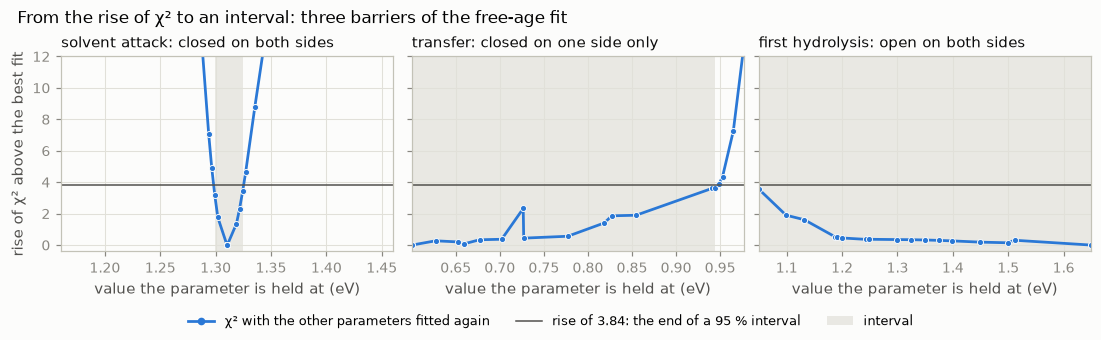

In [ ]:
fit_plots.plot_profile_cases(profiles['free'], {'g solvent_attack': 'solvent attack: closed on both sides', 'g transfer': 'transfer: closed on one side only',
                                                'g hydrolysis_R1': 'first hydrolysis: open on both sides'},
                             title='From the rise of χ² to an interval: three barriers of the free-age fit');

**How to read it**

- **Left:** χ² rises steeply on both sides. The data fix this barrier: 1.30–1.33 eV.
- **Middle:** χ² rises only on the right. Every value from the lowest the search allowed (0.60 eV) up to 0.95 eV fits; the data give an upper limit and no value.
- **Right:** χ² stays under the line over the whole range that was tried. The data do not determine this barrier.
- A single point above its neighbours (middle panel) is a re-fit that stopped in a worse solution. The interval is read from the lowest points.

**All five barriers**

- **Figure:** the same for every barrier, under the three readings. Dot: best fit. Bar: 95 % interval. Arrow: a side with no limit. Pale track: the range the search was allowed.
- **On the axis:** g, the number the fit moves. **Table:** ΔG‡ of each reaction for the best fits, which is g corrected by the reaction energy (step 1 of §3) and is what sets the rate.

reading,1 day,7 days,free ages
ΔG‡ of the best fit (eV),,,
R1 · first hydrolysis,1.32,1.20,1.62
R2 · second hydrolysis,0.96,1.04,0.97
R3 · third hydrolysis,0.98,1.06,0.99
R5 · first transfer,0.58,0.48,0.51
R4 · condensation,1.24,1.24,1.24
R8 · solvent attack,1.29,1.29,1.29


reading,1 day,7 days,free ages
value,,,
age of 2 % H2O (h),fixed by the reading,fixed by the reading,≥ 9
water of TMSPa alone (mM),53–76,150–271,≥ 52


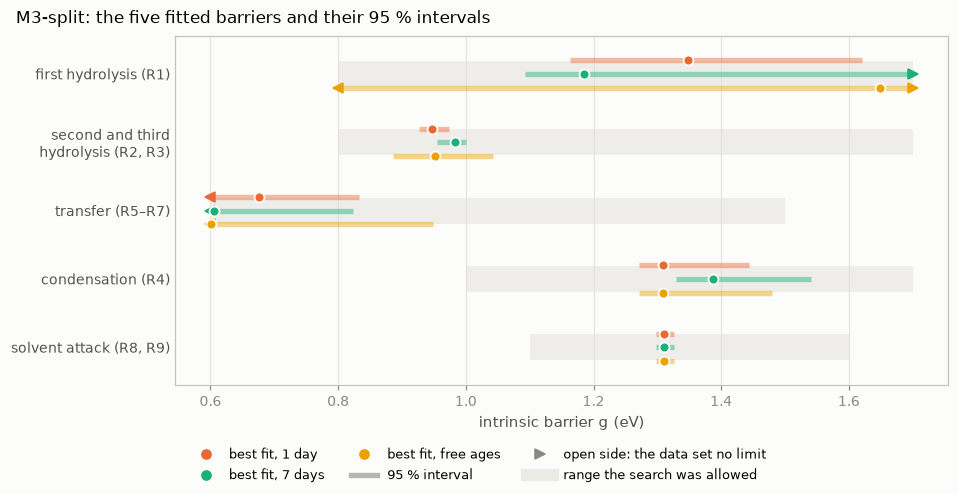

In [ ]:
fit_plots.plot_parameter_intervals(parameters, intervals, structure=MAIN, names=BARRIER_NAMES, boxes={name: BARRIER_BOX_EV[name[2:]] for name in BARRIER_NAMES},
                                   scenarios=FITTING, xlabel='intrinsic barrier g (eV)', title=f'{MAIN}: the five fitted barriers and their 95 % intervals');
display(by_age(main.pivot(index='reaction', columns='scenario', values='dG_barrier_eV')).loc[['R1', 'R2', 'R3', 'R5', 'R4', 'R8']].round(2)
        .rename(index=fit_plots.REACTION_LABELS).rename_axis(index='ΔG‡ of the best fit (eV)'))
other = intervals[intervals['parameter'].isin(['c0 H2O TMSPa alone', 'log10 age 2 % H2O'])].copy()
other.loc[other['parameter'] == 'log10 age 2 % H2O', ['best', 'low', 'high']] = 10.0 ** other.loc[other['parameter'] == 'log10 age 2 % H2O', ['best', 'low', 'high']]
other.loc[other['parameter'] == 'c0 H2O TMSPa alone', ['best', 'low', 'high']] *= 1000.0
other.assign(value=other['parameter'].map({'c0 H2O TMSPa alone': 'water of TMSPa alone (mM)', 'log10 age 2 % H2O': 'age of 2 % H2O (h)'}),
             reading=other['scenario'].map(AGES), interval=[tables.format_interval(row, '.0f') for _, row in other.iterrows()]).pivot(
    index='value', columns='reading', values='interval').reindex(columns=[AGES[s] for s in FITTING]).fillna('fixed by the reading')

**What we see**

| Fitted number | Under the three readings | Verdict |
|---|---|---|
| solvent attack | 1.30–1.33 eV every time | **known**, to ±0.015 eV |
| second and third hydrolysis | 0.89–1.04 eV | **known**, to ±0.08 eV |
| condensation | 1.27–1.54 eV | known, to about ±0.1 eV |
| transfer | below 0.83 eV (1 day), 0.82 eV (7 days), 0.95 eV (free ages); the best fits sit at or near the lowest value the search allowed | **an upper limit only** |
| first hydrolysis | 1.16–1.62 eV at 1 day; above 1.09 eV at 7 days; nothing with free ages | **not known** |
| water of `TMSPa alone` | 53–76 mM at 1 day; 150–271 mM at 7 days; above 52 mM with free ages | depends on the reading |

- **This is close to what 2.2 led us to expect.** The numbers that set end states (the energies of 5.1) and the two barriers seen in the heated TMSOH tubes come out. The two barriers that set how TMSPA is consumed (first hydrolysis, transfer) do not.
- **The aim of the third fit was not reached.** `TMSPa alone` was added to give the transfer barrier a value. It gives an upper limit, as before.

--> 5.3 asks whether the fitted numbers can be moved independently.

### 5.3 Do the fitted numbers depend on each other?

- **What is computed:** the correlation between every pair of fitted numbers, at the best fit with free ages.
- **What a correlation means here:** push one number up a little and re-fit. If a second number has to follow it up, the two are correlated (+1, red). If it has to go down, they are anti-correlated (−1, blue). If it does not care, the correlation is 0 (grey).
- **Why it matters:** two numbers with a correlation near ±1 are not two results. The data fix one combination of them.
- **Limit:** this is a local picture, valid close to the best fit. For a number that the data do not determine (5.2) it shows the direction of the trade, not its size.

,free ages,1 day
the same pairs under two readings,,
R1 against transfer,-0.94,-0.95
energy R3 against energy R4,-0.99,-0.99
"solvent attack against any other, largest",0.02,0.01


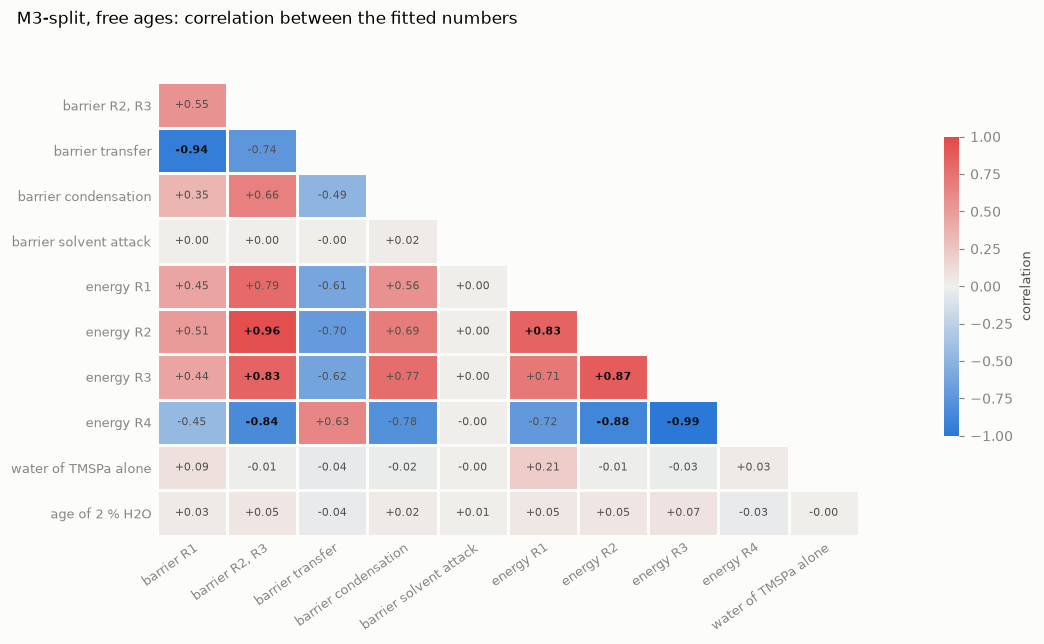

In [ ]:
correlation = {scenario: calculate_parameter_correlation(fits[scenario], observables)['correlation'] for scenario in ('free', 'middle')}
fit_plots.plot_correlation(correlation['free'], labels=SHORT_NAMES, title=f'{MAIN}, free ages: correlation between the fitted numbers');
pairs = {'R1 against transfer': ('g hydrolysis_R1', 'g transfer'), 'energy R3 against energy R4': ('dG R3', 'dG R4'),
         'solvent attack against any other, largest': ('g solvent_attack', None)}
pd.DataFrame({AGES[scenario]: {label: matrix.loc[a, b] if b else matrix.loc[a].drop(a).abs().max() for label, (a, b) in pairs.items()}
              for scenario, matrix in correlation.items()}).round(2).rename_axis('the same pairs under two readings')

**What we see**

- **Solvent attack stands alone:** its row is grey. It is fixed by the TMSOH tubes and nothing else can compensate for it.
- **First hydrolysis and transfer trade against each other** (−0.94): TMSPA can be consumed by water or by TMSOH, and the tubes cannot tell which. Raise one barrier, lower the other, and the fit is the same. This is why neither has a value in 5.2.
- **The four energies move as one block,** and with free ages the barriers of R2–R3 and of condensation move with them. R3 and R4 are tied almost exactly (−0.99): the resting `2 % H2O` tube fixes one combination of the two far better than either one.
- **The water of `TMSPa alone` and the age of `2 % H2O` are tied to nothing** (0.2 at most). The age can be anything above 9 h (5.2) because that tube no longer changes.
- **At 1 day the picture is the same** (table): solvent attack alone, R1 against transfer, R3 against R4.

--> The fit has fewer independent results than fitted numbers. §6 turns to the assumption behind the two barriers that are missing.

## 6. The unknown age

**What this part delivers:** what an age is, why the fit depends on it, and what a trace of TMSOH at mixing does.

### 6.1 What an age is, and why it matters

- **Age:** the time between mixing a tube and recording its first spectrum. Nobody wrote it down. Only `TMSOH, glovebox` comes with a history, taken from the paper.
- **Why it matters:** most tubes give one composition. A composition says how far a reaction has gone, not how long it took. "Slow reaction, old tube" and "fast reaction, young tube" give the same spectrum, so every barrier that sets a speed depends on the age that is assumed.
- **Way out:** every fit is made under four readings of the ages.

| Name in the result files | Shown here as | Reading |
|---|---|---|
| `short` | **1 h** | every tube was 1 h old at its first spectrum |
| `middle` | **1 day** | every tube was 1 day old |
| `long` | **7 days** | every tube was 7 days old |
| `free` | **free ages** | each tube has its own age, between 1 h and 30 days, chosen by the fit |

- **How to use them:** a result that is the same under every reading is set by the data. A result that changes with the reading is set by the assumption.
- **Figure:** the TMSPA share of the three tubes mixed with TMSPA and no TMSOH, from mixing on, for the best fit under each reading. A marker is a measured share, placed at the age the reading gives its tube.
- **Table:** hours from mixing until half of the TMSPA is gone.

reading,1 day,7 days,free ages
hours until half of the TMSPA is gone,,,
0.5 % H2O,49.0,313.0,167.0
2 % H2O,13.0,73.0,43.0
TMSPa alone,210.0,369.0,693.0


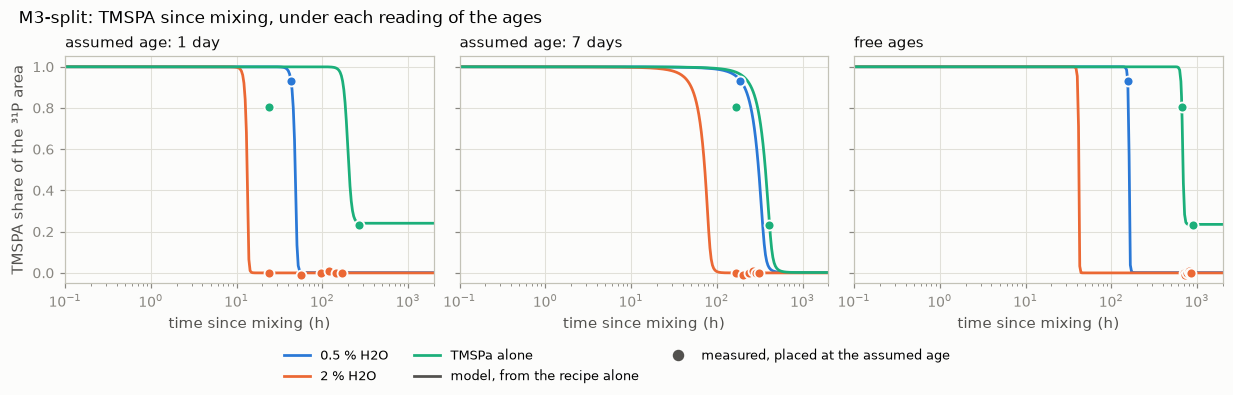

In [ ]:
reading_views = {scenario: tabulate_window_amounts(simulate_fit_trajectories(views[scenario], until_h=2000.0), '31P') for scenario in FITTING}
fit_plots.plot_reading_trajectories(reading_views, shares, samples=WAITING_TUBES, title=f'{MAIN}: TMSPA since mixing, under each reading of the ages');


def tabulate_half_times(curves):
    # Hours from mixing until the TMSPA share first falls below one half, per tube and reading
    rows = {}
    for scenario, curve in curves.items():
        share = curve['TMSPA'] / curve[['TMSPA', 'BMSPA', 'MMSPA', 'H3PO4']].sum(axis=1)
        rows[scenario] = curve[share < 0.5].groupby('sample')['t_h'].min()
    return by_age(pd.DataFrame(rows)).loc[WAITING_TUBES].round(0)


tabulate_half_times(reading_views).rename_axis(index='hours until half of the TMSPA is gone')

**How to read it**

- Each curve is a tube according to the model: flat at 1 (all TMSPA), then a fall. Each marker has to sit on the curve of its colour.
- Moving a marker left or right is what "assuming another age" means. The fit answers by moving the fall.

**What we see**

- **Under every reading the model waits and then falls.** The readings differ in when: `2 % H2O` falls after 13 h, 73 h or 43 h. At 7 days the fall is slower than under the other two.
- **`0.5 % H2O` is always caught at the start of its fall.** Its one spectrum shows 93 % TMSPA. Each fit puts the fall just after it, whatever the age: half gone after 49 h for a spectrum taken at 43 h (1 day), and after 167 h for a spectrum taken at 155 h (free ages).
- **`TMSPa alone` is the only tube with two markers.** At 1 day and 7 days its first marker (81 %) lies below the curve: this is the worst miss of those two fits (2.96 and 2.56, §4). With free ages the fit makes the tube 27 days old at its first spectrum: one marker sits at the start of the fall and the other after it.
- **Why the model waits:** in these fits first hydrolysis is slow (ΔG‡ 1.2–1.6 eV, 5.2) and transfer fast (0.5–0.6 eV). TMSPA is then consumed by TMSOH, and the later hydrolysis steps give TMSOH back. TMSOH multiplies, slowly at first, then all at once. Nothing is visible until there is enough of it.

--> A reaction that starts itself can be started early by what is already in the tube. 6.2 tests that.

### 6.2 A trace of TMSOH at mixing

**Context**

- **What every fit assumes:** a tube starts from its recipe alone. No TMSOH is there at mixing.
- **Why doubt it:** the first spectrum of `TMSPa alone` already shows 12 % BMSPA, and `0.5 % H2O` shows 6 %. Each BMSPA has released a silyl group. A TMSPA stock that has seen moisture would hold some of these products before it is mixed.
- **Why it matters for this model:** the wait of 6.1 lasts as long as it takes the first TMSOH to appear. If some is there from the start, the wait is shorter and the fall comes earlier.

**Test**

- The fitted numbers are kept as they are. TMSOH is added at mixing to the three tubes of 6.1: 1 µM (7 parts per million of the TMSPA) or 1 mM (0.7 %).
- **Trace rule of the third fit:** a fit is accepted only if it still fits (worst miss 3 or less) with both amounts.
- **Table:** the worst miss without and with the trace. **Figure:** the curves of 6.1, with 1 mM as dashed lines. The markers stay where 6.1 put them.

,no TMSOH at mixing,with 1 µM,with 1 mM,passes the rule
"worst miss, fitted numbers unchanged",,,,
1 day,3.0,37.1,30.0,no
7 days,2.6,2.6,13.8,no
free ages,1.9,1.9,29.8,no


reading,1 day,7 days,free ages
with 1 mM TMSOH: hours until half of the TMSPA is gone,,,
0.5 % H2O,11.0,232.0,13.0
2 % H2O,3.0,56.0,3.0
TMSPa alone,60.0,283.0,73.0


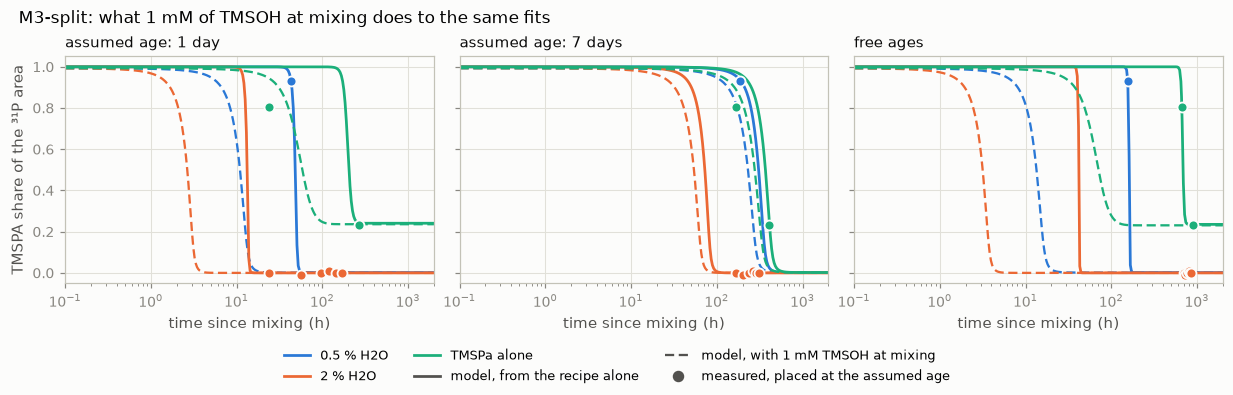

In [ ]:
verdict = pd.read_csv(RESULTS / 'trace_verdict.csv').set_index('scenario').loc[list(FITTING)].rename(index=AGES)
display(pd.DataFrame({'no TMSOH at mixing': verdict['max |z|'], 'with 1 µM': verdict['max |z| with 1e-06 M'], 'with 1 mM': verdict['max |z| with 1e-03 M'],
                      'passes the rule': verdict['passes'].map({True: 'yes', False: 'no'})}).round(1).rename_axis(index='worst miss, fitted numbers unchanged'))
trace = {tube: {'added_M': {'TMSOH': 1e-3}} for tube in WAITING_TUBES}
traced = {scenario: evaluate_fit(fits[scenario], observables, overrides=trace, ages=views[scenario]['ages']) for scenario in FITTING}
traced_views = {scenario: tabulate_window_amounts(simulate_fit_trajectories(view, until_h=2000.0), '31P') for scenario, view in traced.items()}
fit_plots.plot_reading_trajectories(reading_views, shares, samples=WAITING_TUBES, traced=traced_views, trace_label='model, with 1 mM TMSOH at mixing',
                                    title=f'{MAIN}: what 1 mM of TMSOH at mixing does to the same fits');
tabulate_half_times(traced_views).rename_axis(index='with 1 mM TMSOH: hours until half of the TMSPA is gone')

**What we see**

- **With 1 mM every fall comes earlier:** about 4 times earlier at 1 day, 10 times or more with free ages, and by about a quarter at 7 days. The markers are left behind: the fits no longer describe the tubes.
- **No fit passes the rule.**
  - 1 day fails already with 1 µM (worst miss 37).
  - 7 days is not moved by 1 µM and fails with 1 mM (14).
  - Free ages pass with 1 µM and fail with 1 mM (30).
- **Why free ages pass with 1 µM:** the fit may choose the ages again, and it makes the tubes younger to follow the earlier fall. With 1 mM the fall of `0.5 % H2O` comes 13 h after mixing. Its spectrum was recorded 19 h after the first file of that tube, so no age can put it before the fall.

**What this means**

- The barriers of first hydrolysis and transfer in these fits describe a tube that starts perfectly clean. They are set by that assumption as much as by the spectra.
- The 1 mM level is a declared choice. Whether the stock was cleaner than that is a question for the lab, not for the fit.

--> The wait-then-fall description cannot be confirmed with these tubes. §7 checks the tools: the method and the error bars.

## 7. Can the method and the error bars be trusted?

**What this part delivers:** a test of the fitting method on data whose answer is known, and a look at the error of a share: what is declared, and what can be checked.

### 7.1 The method on invented data

**The idea**

1. Choose a set of barriers and energies and call it the truth.
2. Let the model make the shares that the lab tubes would show with that truth: same tubes, same times, same errors. Add random noise of the size of the errors.
3. Hand these invented shares to the fit, without the answer.
4. Compare what comes back with the truth.

- If the method works, the fitted values land near the truth and the 95 % intervals contain it (about 19 times in 20).
- If a number comes back as "not determined" here, where the model is right by construction, the tubes cannot determine it. A fit of the lab data cannot be expected to do better.

**Three cases, seven invented data sets**

| Case | Model that made the data | Reading | Data sets |
|---|---|---|---|
| A | M1-split | 1 day | 3 |
| B | M3-split, energies of R2 and R3 moved from DFT | 1 day | 2 |
| C | M3-split, free ages, transfer barrier 0.75 eV, water of `TMSPa alone` 60 mM: close to what the third fit was expected to find | free ages | 2 |

- **Table:** per case, χ² of the fit against χ² of the true numbers, and how many true values lie inside their interval.
- **Figure:** fitted value minus true value, for every number and data set. Everything should sit on the black line, and every bar should cross it.

,χ² of the fit,χ² of the true numbers,true values inside their interval,intervals
case,,,,
"A, seed 1",41.4,44.8,5,5
"A, seed 2",51.0,58.9,5,5
"A, seed 3",63.4,69.2,4,5
"B, seed 1",44.4,47.4,7,7
"B, seed 2",57.8,61.5,7,7
"C, seed 1",43.9,48.5,8,8
"C, seed 2",53.3,63.0,5,8


water of TMSPa alone (mM),truth,fit,low,high,truth inside
case,,,,,
"C, seed 1",60.0,53.0,46.0,NaN,True
"C, seed 2",60.0,249.0,183.0,NaN,False


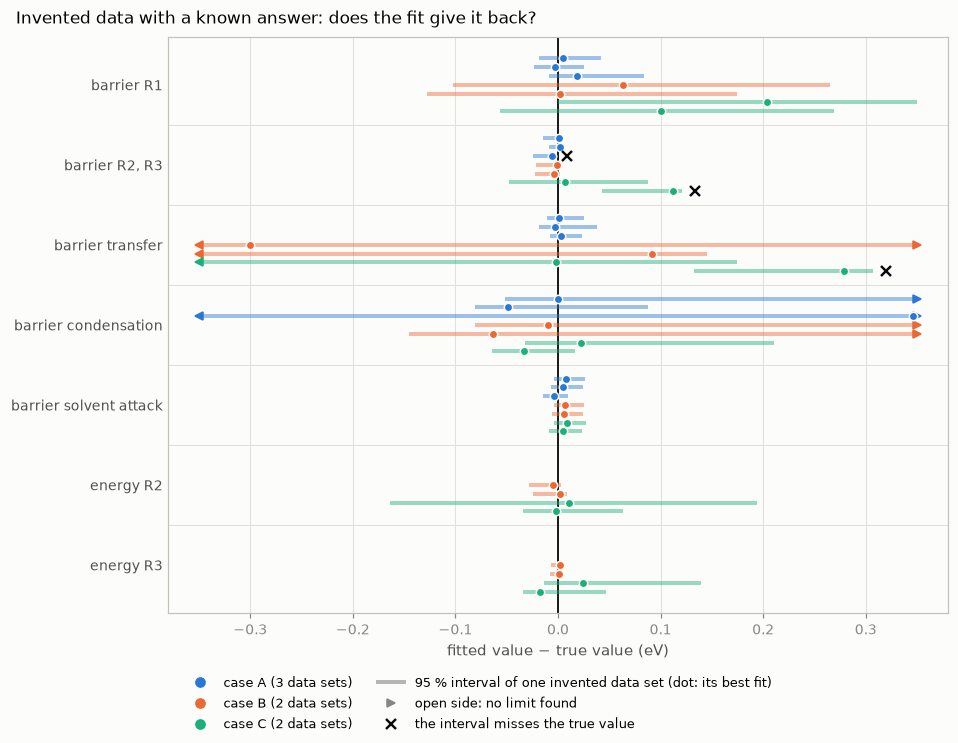

In [ ]:
recovery = pd.read_csv(RESULTS / 'recovery_summary.csv')
display(recovery.groupby('case').agg(**{'χ² of the fit': ('chi2 fit', 'first'), 'χ² of the true numbers': ('chi2 truth', 'first'),
                                        'true values inside their interval': ('truth inside', 'sum'), 'intervals': ('truth inside', 'size')}).round(1))
fit_plots.plot_recovery_offsets(recovery, names={name: SHORT_NAMES[name] for name in recovery['parameter'].unique() if name != 'c0 H2O TMSPa alone'},
                                cases={'A': 'case A (3 data sets)', 'B': 'case B (2 data sets)', 'C': 'case C (2 data sets)'});
water = recovery[recovery['parameter'] == 'c0 H2O TMSPa alone'].set_index('case')
(1000 * water[['truth', 'fit', 'low', 'high']]).round(0).assign(**{'truth inside': water['truth inside']}).rename_axis('water of TMSPa alone (mM)', axis=1)

**How to read it**

- **Narrow bars on the line:** the number is found, and found precisely. **Wide bars or arrows:** the tubes do not determine it, even with the right model.
- **A cross:** the interval excludes the truth. With 45 intervals at 95 %, two or three crosses are expected.

**What we see**

- **The search works:** in all seven data sets the fit reaches a χ² below that of the true numbers.
- **Found every time:** solvent attack (to ±0.02 eV), and in case B the energies of R2 and R3.
- **Not determined even with the right model:** condensation in cases A and B (arrows), and transfer in cases B and C. For transfer this matches 5.2: an upper limit at most.
- **Four intervals miss, 41 of 45 hold the truth** (three crosses in the figure, and the water in the table). One miss is in case A, by 0.003 eV. **The other three are one data set of case C:** there the fit came back with a transfer barrier 0.28 eV too high, an R2–R3 barrier 0.11 eV too high and 249 mM of water where the truth was 60 mM, and all three intervals exclude the truth.

**What this means**

- The run counts this as passed: the declared criterion is at most 15 % of the true values outside.
- Read by case it says more. Case C is the one that resembles the third fit, and in one of two tries it returned a wrong, confident answer for transfer, for the water and for the R2–R3 barrier. With free ages the limits that 5.2 gives for these three can be wrong, not only wide.

--> The method finds what the tubes determine. It can be confidently wrong on what they do not. 7.2 looks at the errors that every miss is measured in.

### 7.2 The error of a share: what is declared, what is checked

**Why this matters:** every miss is a difference divided by an error. If the errors are too small, a good model fails the rule; if they are too large, a wrong model passes.

**What the error of a share is made of**

| Part | Where it comes from | Declared or measured |
|---|---|---|
| noise | the scatter of the spectrum where there is no line | measured, per spectrum |
| baseline | the share is computed with three different baselines; half their spread | measured, per spectrum |
| floor | what the two parts above cannot see (lines that relax or are enhanced differently). ³¹P: the larger of 0.01 and 5 % of the share. ¹³C: the larger of 0.03 and 15 % | **declared** before any fit |

- The three are added in quadrature.
- **Figure:** the size of each part, one dot per measured share.

,noise (measured),baseline (measured),floor (declared),all three together
median error of a share,,,,
13C,0.014,0.020,0.03,0.053
31P,0.005,0.012,0.01,0.032


,floor (declared),baseline (measured),noise (measured)
shares in which this part is the largest,45,25,10


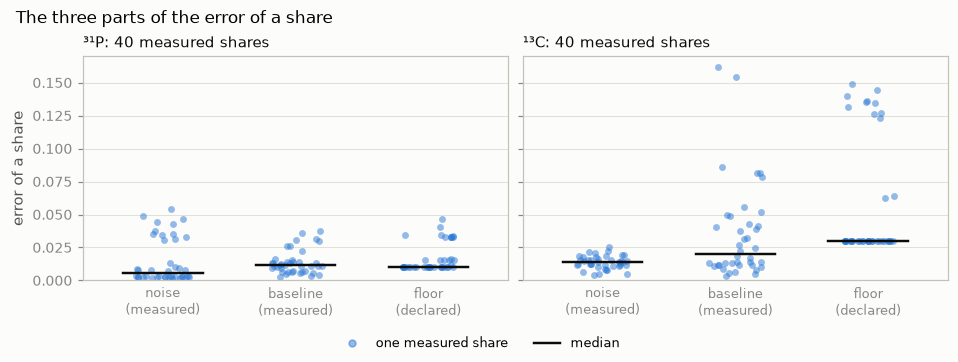

In [ ]:
measured = tabulate_observable_shares(observables).query("role == 'fit'").copy()
floor = observables['_meta']['error_floor']
measured['floor'] = [max(floor[n]['absolute'], floor[n]['relative'] * max(s, 0.0)) for n, s in zip(measured['nucleus'], measured['share'])]
parts = {'sigma_noise': 'noise\n(measured)', 'sigma_baseline': 'baseline\n(measured)', 'floor': 'floor\n(declared)'}
fit_plots.plot_error_parts(measured, parts=parts, title='The three parts of the error of a share');
measured['total'] = np.sqrt((measured[list(parts)] ** 2).sum(axis=1))
names = {**{column: label.replace('\n', ' ') for column, label in parts.items()}, 'total': 'all three together'}
display(measured.groupby('nucleus')[list(names)].median().rename(columns=names).round(3).rename_axis('median error of a share'))
measured[list(parts)].idxmax(axis=1).map(names).value_counts().rename('shares in which this part is the largest').to_frame().T

**What we see**

- **The declared floor is the largest part in more than half of the shares** (45 of 80). The error bars of this fit are to a large extent a declaration, not a measurement.
- The measured parts are of the same order. Together the three give a share an error of about 0.03 on ³¹P and 0.05 on ¹³C (medians; a share runs from 0 to 1).

**Check 1: the same tube measured six times**

- `2 % H2O` was measured six times at room temperature and its composition did not change. The six spectra are six tries at the same shares.
- **Figure:** each share minus the mean of its six values. The bar is the noise of that spectrum.
- **How to read:** if noise were the whole story, about two bars in three would cross the zero line.

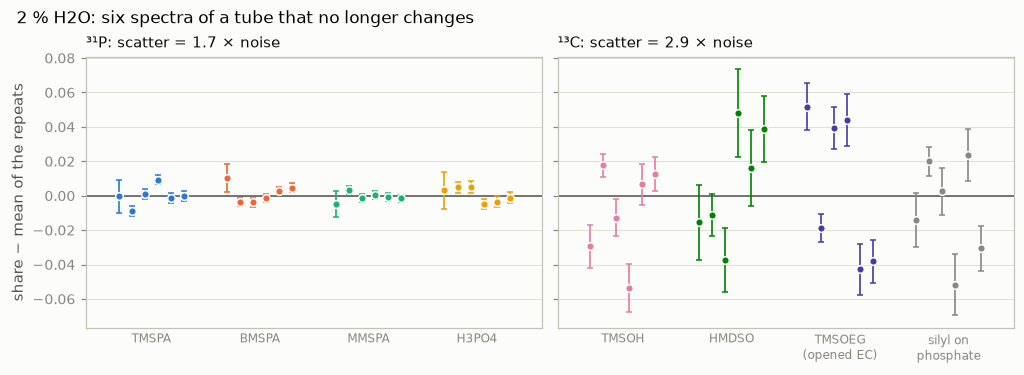

In [ ]:
scatter = {nucleus: calculate_replicate_scatter(observables, '2 % H2O', nucleus)['birge'] for nucleus in ('31P', '13C')}
fit_plots.plot_replicates(measured, sample='2 % H2O', scatter=scatter, title='2 % H2O: six spectra of a tube that no longer changes');

- **The six values scatter more than their noise:** 1.7 times on ³¹P and 2.9 times on ¹³C. Something besides noise changes from spectrum to spectrum (the baseline, for example).
- **What the fit does with this:** for this tube the noise is multiplied by these factors. It is the only tube where the error can be checked this way; the others have one spectrum.

**Check 2: are the misses as large as the errors say?**

- If the errors are right and the model is right, the misses of a fit scatter like a bell curve of width 1: two in three within ±1, χ² close to the number of values minus the number of fitted numbers.
- **Figure:** the misses of the free-age fit against that curve (93 rows: the 85 values, with the "no change" of `2 % H2O` listed for each of its spectra).
- **Table:** the same fitted numbers scored with the declared floor removed, as it is, and doubled.

85% of the misses are within ±1 (bell curve: 68 %). χ² = 35.3 for 85 values and 11 fitted numbers (expected: about 74).


,χ²,worst miss,where the worst miss is,fits
"same fitted numbers, free ages",,,,
floor removed,59.8,3.3,"TMSOH, probe: TMSOH",no
floor as declared,35.3,1.9,"2 % H2O: TMSPA drift, spectrum 4",yes
floor doubled,31.7,1.9,"2 % H2O: TMSPA drift, spectrum 4",yes


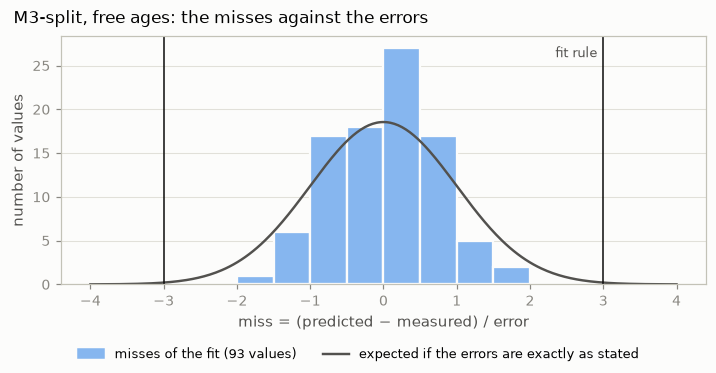

In [ ]:
table = fits['free']['table']
fit_plots.plot_miss_distribution(table, title=f'{MAIN}, free ages: the misses against the errors');
within = (table['z'].abs() < 1.0).mean()
print(f"{within:.0%} of the misses are within ±1 (bell curve: 68 %). χ² = {fits['free']['chi2']:.1f} for {fits['free']['n_residuals']} values and "
      f"{fits['free']['n_parameters']} fitted numbers (expected: about {fits['free']['n_residuals'] - fits['free']['n_parameters']}).")
rows = {}
for scale, label in ((0.0, 'floor removed'), (1.0, 'floor as declared'), (2.0, 'floor doubled')):
    problem = FitProblem(MAIN, build_sample_set(observables, 'free', floor_scale=scale), solver=REPORT_SOLVER)
    x = problem.vector(fits['free']['theta'])
    scored = problem.table(x)
    worst = scored.loc[scored['z'].abs().idxmax()]
    rows[label] = {'χ²': round(problem.chi2(x), 1), 'worst miss': round(abs(worst['z']), 1),
                   'where the worst miss is': f"{worst['sample']}: {worst['quantity']}", 'fits': 'yes' if abs(worst['z']) <= 3.0 else 'no'}
pd.DataFrame(rows).T.rename_axis('same fitted numbers, free ages')

**What we see**

- **The misses are smaller than the errors say.** 85 % lie within ±1 where 68 % are expected, and χ² is 35 where about 74 is expected. The error bars are generous, by a factor of about 1.4.
- **Without the declared floor the same numbers do not pass the rule** (worst miss 3.3, the TMSOH line of `TMSOH, probe`; the fit is not made again here). With the floor doubled nothing changes.
- **So the verdict "fits" leans on the floor.** It is not too small: the misses say it is, if anything, too large. But it is declared, and the fit rule (worst miss 3 or less) is only as sharp as that declaration.

**Not tested here**

- The fits made again with other declared choices (floor, the errors of the DFT energies, the length of the heating steps, the 8 h of the glovebox). Those runs of the third fit were not finished when this draft was written.

--> The errors are on the safe side. §8 collects what can be said.

## 8. What can be said, and what cannot

**Can be said: the same under the three readings, with a closed interval**

| What | Value | Rests on |
|---|---|---|
| The model | M3-split is the simplest one that fits: R1 separate from R2–R3, and the energies of R1–R4 free (§4) | all tubes |
| Solvent attack | g = 1.30–1.33 eV; ΔG‡(R8) = 1.29 eV at 80 °C. Tied to no other number (5.3) | the TMSOH tubes; no single tube moves it by more than 0.02 eV |
| Second and third hydrolysis | g = 0.89–1.04 eV. With free ages one invented data set in two missed it by 0.04 eV (7.1) | `2 % H2O` (up to +0.24 eV without it) |
| Condensation | g = 1.27–1.54 eV; ΔG‡(R4) = 1.24 eV at 80 °C | `TMSOH, glovebox` and `2 % H2O` |
| Reaction energies of R1–R4 | 0.7σ to 1.9σ from DFT (5.1). 1 day and free ages agree to 0.01 eV; 7 days lies about 0.1 eV further | `2 % H2O`, taken as resting at equilibrium (without it the energies of R1–R3 lie 0.13 to 0.35 eV closer to DFT) |

- **Last column:** read from the fits made again without each tube in turn (`loo/` in the results folder), which are not shown here.
- `2 % H2O` carries most of the fit: without it χ² falls from 35–46 to 9–12.

**Cannot be said**

| Open point | Why | What would close it |
|---|---|---|
| How TMSPA is consumed: by water (R1) or by TMSOH (transfer) | the two barriers trade against each other (5.3); R1 has no interval with free ages and transfer only an upper limit (5.2) | one tube followed in time at room temperature from a known mixing time |
| The transfer barrier, the aim of the third fit | `TMSPa alone` gave an upper limit only; on invented data of the same kind the fit returned a wrong value in one of two tries (7.1) | the same |
| Whether the tubes wait and then fall | no tube is followed through a fall; 1 mM of TMSOH at mixing moves every fall and no fit survives it (6.2) | the purity of the TMSPA stock; a tube followed in time |
| The water of `TMSPa alone` | 53–76 mM, 150–271 mM or above 52 mM, depending on the reading (5.2) | a water measurement of the solvent |
| The ages | not recorded; with free ages the fit makes `TMSPa alone` 27 days old at its first spectrum, which nothing confirms (6.1) | the mixing times |

**Left out of this draft on purpose**

- Results that exist in `notebooks/results/05_fit3/` and are not shown: the fits made without each tube in turn (only quoted above), and the four registered models scored as they are.
- Results that were still being computed: the fits with a trace of TMSOH made again, the sensitivity to the declared choices, the test "equilibrium or water run out", the predictions (storage, bench protocol) and tube B.